<a href="https://colab.research.google.com/github/Kmpi17/TFMGreenWashing/blob/main/TFG_KMPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

En el siguiente trabajo se buscan dos objetivos.

El primero de ellos es realizar un estudio sobre el greenwashing que puede llegar a haber en los productos alimenticios españoles y cuales son las compañias que mas abusan de el, para aquellos que no estan familiarizados con el termino esto es una estrategia de marketing que realizan muchas empresas para mejorar la imagen de los productos y aparentar que estos son mas saludables,ecologicos, naturales o sostenibles.

El segundo es hacer un modelo que sea capaz de detectar productos y pueda sesgarlos en diferentes grupos para que el consumidor pueda ver si tiene greenwashing de que forma le estan engañando


In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import gdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler

file_id='1TIVB9XokgA-2zQrHpkZbu-Zb1fvor87J'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'productos_espana.csv'
gdown.download(url, output, quiet=False)
df_products = pd.read_csv(output, low_memory=False)
print("Archivo cargado con éxito")

Downloading...
From (original): https://drive.google.com/uc?id=1TIVB9XokgA-2zQrHpkZbu-Zb1fvor87J
From (redirected): https://drive.google.com/uc?id=1TIVB9XokgA-2zQrHpkZbu-Zb1fvor87J&confirm=t&uuid=6b2b46ed-712b-4e2c-b508-552493e72743
To: /content/productos_espana.csv
100%|██████████| 1.06G/1.06G [00:12<00:00, 83.4MB/s]


Archivo cargado con éxito


# **ANALISIS PREVIO DEL DATASET**

Celda usada para ver en mas profundidad el contenido del dataset

In [143]:
print("TODO LOS NOMBRE DE COLUMNAS ")
print(df_products.columns.tolist())
print("------------")
print(df_products.iloc[1900].to_string())

TODO LOS NOMBRE DE COLUMNAS 
['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime', 'product_name', 'abbreviated_product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'packaging_en', 'packaging_text', 'brands', 'brands_tags', 'brands_en', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'origins_en', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'nutriscore_score', 'nutriscore

Celda usada para ver informacion generica sobre el dataset

In [144]:
print("Numero de columnas y nombres")
print(df_products.columns)
print("------------")
print(f"Total de columnas {len(df_products.columns)}")
print("------------")
print(f"Totel de registros {len(df_products)}")
print("------------")
print(f"Valores nulos")
nulos=df_products.isnull().sum().sum()
print(nulos)
print("------------")
print("Valores duplicados")
duplicados=df_products.duplicated().sum()
print(duplicados)
print("------------")
print("Tipos de datos")
print(df_products.dtypes)
print("------------")


Numero de columnas y nombres
Index(['code', 'url', 'creator', 'created_t', 'created_datetime',
       'last_modified_t', 'last_modified_datetime', 'last_modified_by',
       'last_updated_t', 'last_updated_datetime',
       ...
       'water-hardness_100g', 'choline_100g', 'phylloquinone_100g',
       'beta-glucan_100g', 'inositol_100g', 'carnitine_100g', 'sulphate_100g',
       'nitrate_100g', 'acidity_100g', 'carbohydrates-total_100g'],
      dtype='object', length=209)
------------
Total de columnas 209
------------
Totel de registros 352707
------------
Valores nulos
60038572
------------
Valores duplicados
0
------------
Tipos de datos
code                         object
url                          object
creator                      object
created_t                     int64
created_datetime             object
                             ...   
carnitine_100g              float64
sulphate_100g               float64
nitrate_100g                float64
acidity_100g               

# **PROCESO DE LIMPIEZA**

El proceso de limpieza es de gran importancia en este caso mas que nunca debido a que el dataset que se va a utilizar es de una bbdd no relacional comunitaria, esta se llama Open Food Facts, el problema de esta es que al ser comunitaria hay una gran cantidad de informacion que esta incompleta o puede llegar a ser erronea

Previamente vamos al dataset a hacer una copia en una variable para posteriormente comparar entre ellos todos los cambios

In [145]:
df_products_copy=df_products.copy()

ELIMINACION DE FILAS VACIAS

In [146]:
print(f"Totel de registros antes:{len(df_products_copy)}")
df_products_copy=df_products_copy.dropna(how="all")
print(f"Totel de registros despues:{len(df_products_copy)}")

Totel de registros antes:352707
Totel de registros despues:352707


LIMPIEZA DE COLUMNAS INECESARIAS

En este caso se ha llegado a la conclusion de elegir estas columnas debido a que para este caso se buscan columnas donde se pueda relacionar la relacion que pueden llegar a tener la nutricion, marketing y aditivos de un producto, por tanto se ha decidido quedarse con la informacion basica del producto como la categoria, marcas, para asi en un futuro poder realizar un estudio concreto sobre que marcas hacen que relacionado con el Greenwashing al igual que se hara con las etuqietas que viene en los productos o el nutriscore debido a que son principalmente las dos formas en la que mienten las compañias alimentarias, todo lo demas seria informacion irelevente y redundante.

In [147]:
print(f"Numero de columnas antes:{len(df_products_copy.columns)}")
columnas_utilizadas=['code', 'product_name', 'brands', 'categories_en', 'labels_tags','nutriscore_grade', 'energy-kcal_100g',
    'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g','additives_n','additives_tags']

df_products_copy=df_products_copy[columnas_utilizadas]

print(f"Numero de columnas despues:{len(df_products_copy.columns)}")

Numero de columnas antes:209
Numero de columnas despues:14


In [148]:
print("\n1️⃣ Información General:")
print(df_products_copy.info())
print("------------")
print("\n2️⃣ Estadísticas Descriptivas:")
display(df_products_copy.describe())


1️⃣ Información General:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352707 entries, 0 to 352706
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                352707 non-null  object 
 1   product_name        332307 non-null  object 
 2   brands              214028 non-null  object 
 3   categories_en       132162 non-null  object 
 4   labels_tags         121580 non-null  object 
 5   nutriscore_grade    351932 non-null  object 
 6   energy-kcal_100g    21416 non-null   float64
 7   fat_100g            21267 non-null   float64
 8   saturated-fat_100g  20817 non-null   float64
 9   sugars_100g         20918 non-null   float64
 10  proteins_100g       21291 non-null   float64
 11  salt_100g           20795 non-null   float64
 12  additives_n         51261 non-null   float64
 13  additives_tags      27818 non-null   object 
dtypes: float64(7), object(7)
memory usage: 37.7+ MB
None
-----

,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,salt_100g,additives_n
count,2.141600e+04,21267.000000,20817.000000,20918.000000,21291.000000,20795.000000,51261.000000
mean,3.569451e+02,12.663792,4.555092,12.646282,7.970327,1.394834,1.845341
std,1.320812e+04,17.026554,7.286075,17.841805,10.135380,23.467640,2.979229
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.400000e+01,1.000000,0.200000,1.300000,2.000000,0.070000,0.000000
50%,2.440000e+02,5.200000,1.600000,4.800000,5.300000,0.220000,1.000000
75%,4.150000e+02,20.000000,5.600000,15.600000,10.000000,1.000000,3.000000
max,1.932459e+06,100.000000,100.000000,420.000000,100.000000,2480.000000,319.000000


**ANALISIS DE COMPLETITUD**

In [149]:
valores_faltantes = df_products_copy.isnull().sum()
porcentaje_faltos = (valores_faltantes / len(df_products_copy)) * 100

df_faltantes = pd.DataFrame({
    'Valores Faltantes': valores_faltantes,
    'Porcentaje de Faltantes': porcentaje_faltos
})

print("Análisis de Completitud de Columnas:")
print(df_faltantes.sort_values(by='Porcentaje de Faltantes', ascending=False))

Análisis de Completitud de Columnas:
                    Valores Faltantes  Porcentaje de Faltantes
salt_100g                      331912                94.104171
saturated-fat_100g             331890                94.097934
sugars_100g                    331789                94.069298
fat_100g                       331440                93.970349
proteins_100g                  331416                93.963545
energy-kcal_100g               331291                93.928105
additives_tags                 324889                92.113000
additives_n                    301446                85.466407
labels_tags                    231127                65.529462
categories_en                  220545                62.529238
brands                         138679                39.318471
product_name                    20400                 5.783838
nutriscore_grade                  775                 0.219729
code                                0                 0.000000


Análisis de Completitud de Columnas (Gráfico):


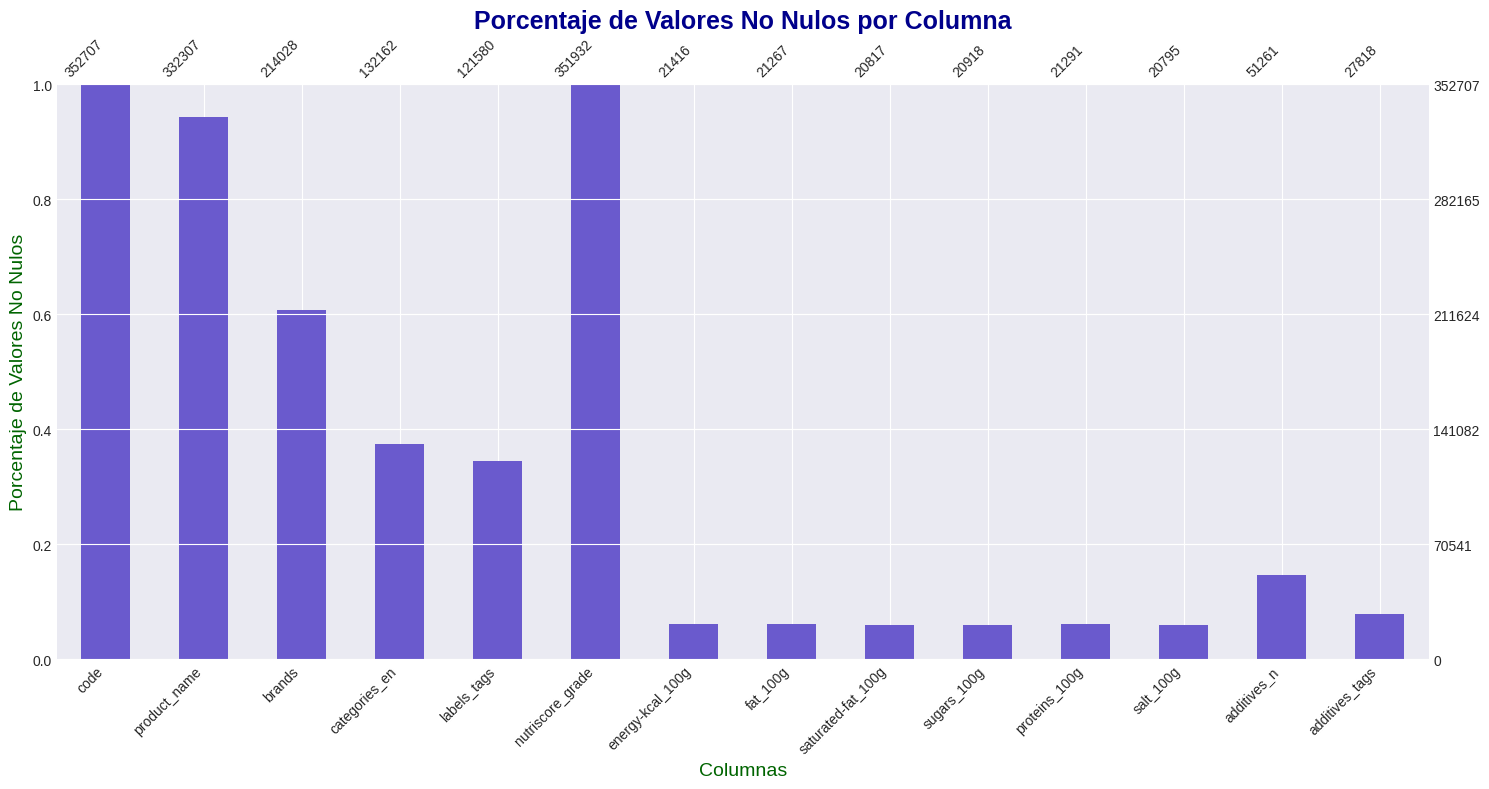

In [150]:

print("Análisis de Completitud de Columnas (Gráfico):")

plt.style.use('seaborn-v0_8-darkgrid')

ax = msno.bar(df_products_copy, figsize=(15, 8), color="#6A5ACD", fontsize=10, labels=True)

ax.set_title('Porcentaje de Valores No Nulos por Columna', fontsize=18, color='darkblue', fontweight='bold')
ax.set_xlabel('Columnas', fontsize=14, color='darkgreen')
ax.set_ylabel('Porcentaje de Valores No Nulos', fontsize=14, color='darkgreen')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**LIMPIEZA DE VALORES NULOS**

en este caso vamos a eliminar todos los registros en los cuales las calorias y los azucares sean nulos debido a que lo que se quiere evitar es que haya productos de limpieza e higiene, tambien si el producto no tiene calorias o azucares en un futuro no podre agruparlos basandolos en lo saludables que pueden ser o no por tanto se va a priorizar la integridad del modelo en un futuro sobre el volumen de datos.

In [151]:
print(f"Totel de registros antes:{len(df_products_copy)}")
df_products_copy=df_products_copy.dropna(subset=['energy-kcal_100g', 'sugars_100g'])
print(f"Totel de registros despues:{len(df_products_copy)}")


Totel de registros antes:352707
Totel de registros despues:20904


In [152]:
print(df_products_copy.iloc[2191].to_string())

code                                                           27025840
product_name                                              Mini Grissini
brands                                                              NaN
categories_en         Plant-based foods and beverages,Plant-based fo...
labels_tags                                                         NaN
nutriscore_grade                                                      d
energy-kcal_100g                                                  427.0
fat_100g                                                           13.0
saturated-fat_100g                                                  2.0
sugars_100g                                                         2.5
proteins_100g                                                      10.0
salt_100g                                                           2.0
additives_n                                                         NaN
additives_tags                                                  

**EXPLICACION DE DISMINUCION**

como se puede ver la cantidad de registros ha disminuido de gran forma esta es debido a que por un lado se esta priorizando la calidad del modelo por tanto no se usaran registros con informacion incompleta ya que nuestro modelo no seria acertado, por otro lado la API utilizada es comunitaria por tanto hay muchos registros "basura" con informacion incompleta, por tanto al priorizarse la calidad frente a la cantidad da este resultado

In [153]:
print(f"Totel de registros antes:{len(df_products_copy)}")
df_products_copy = df_products_copy[
    ((df_products_copy['fat_100g'] +
      df_products_copy['sugars_100g'] +
      df_products_copy['proteins_100g']+
      df_products_copy['salt_100g']) <= 100) &
    (df_products_copy['energy-kcal_100g'] > 0)
]

df_products_copy=df_products_copy[df_products_copy['fat_100g'] >= df_products_copy['saturated-fat_100g']]
df_products_copy=df_products_copy.dropna(subset=['product_name','code','brands','categories_en'])
df_products_copy=df_products_copy.drop_duplicates(subset=['code'])



print(f"Totel de registros despues:{len(df_products_copy)}")

Totel de registros antes:20904
Totel de registros despues:17410


In [154]:
print(df_products_copy.iloc[2191].to_string())

code                                                      3245412404474
product_name                                            Bizcocho al ron
brands                                                        Carrefour
categories_en         Dairies,Snacks,Desserts,Sweet snacks,Biscuits ...
labels_tags           en:non-organic,en:nutriscore,en:nutriscore-gra...
nutriscore_grade                                                      d
energy-kcal_100g                                                  186.0
fat_100g                                                            3.3
saturated-fat_100g                                                  2.2
sugars_100g                                                        25.0
proteins_100g                                                       1.7
salt_100g                                                          0.16
additives_n                                                         2.0
additives_tags                                          en:e410,

En estra celda estan los metodos para limpiar de forma generica algunas columnas.

El metodo normalizar_string() es usado para dar un formato generico al nombre y a las marcas del producto, despues de haber estado mirando casi todos los registros no se ha detectado errores ortograficos en las marcas que es donde esto puede llegar a ser mas clave.

Por otro lado el metodo separar_categorias_marcas() es usado para en aquellas registros en los que ponen varias marcas quedarnos solo con la primera que aparece que suele ser la marca principal.



In [155]:
def normalizar_string(valor):
  if pd.isna(valor):
    return np.nan
  valor=str(valor).lower().strip().replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u").replace("®","").strip()
  return valor

def normalizar_string_marca_concreto(valor):
  if pd.isna(valor):
    return np.nan
  valor=str(valor).lower().strip().replace("bio","").replace("®","").strip()
  return valor

def separar_categorias_marcas(valor):
  if pd.isna(valor):
    return np.nan
  valor=str(valor).split(",")
  return valor[0]


def limpiar_tags_aditivos(valor):
    if pd.isna(valor):
        return "no_tag"
    valor = str(valor).replace('en:', '')
    return valor

En esta celda se esta dando un formato comun para en un futuro faticilar el estudio de los datos.


In [156]:
df_products_copy['product_name']=df_products_copy['product_name'].apply(normalizar_string)
df_products_copy['brands']=df_products_copy['brands'].apply(normalizar_string)
df_products_copy['brands']=df_products_copy['brands'].apply(normalizar_string_marca_concreto)

df_products_copy['categories_en']=df_products_copy['categories_en'].apply(normalizar_string)
df_products_copy['labels_tags']=df_products_copy['labels_tags'].apply(normalizar_string)
df_products_copy['additives_tags']=df_products_copy['additives_tags'].apply(normalizar_string)

df_products_copy['brands']=df_products_copy['brands'].apply(separar_categorias_marcas)
df_products_copy['categories_en']=df_products_copy['categories_en'].apply(separar_categorias_marcas)

df_products_copy['additives_n'] = df_products_copy['additives_n'].fillna(0)
df_products_copy['additives_n'] = df_products_copy['additives_n'].astype(int)


df_products_copy['nutriscore_grade'] = df_products_copy['nutriscore_grade'].replace(['not-applicable', 'unknown'], np.nan)


df_products_copy['additives_tags'] = df_products_copy['additives_tags'].apply(limpiar_tags_aditivos)


en un futuro habra q hacer tablas binarias para entrenar el modelo sobre los tags

In [157]:
print(df_products_copy.iloc[2191].to_string())

code                                                      3245412404474
product_name                                            bizcocho al ron
brands                                                        carrefour
categories_en                                                   dairies
labels_tags           en:non-organic,en:nutriscore,en:nutriscore-gra...
nutriscore_grade                                                      d
energy-kcal_100g                                                  186.0
fat_100g                                                            3.3
saturated-fat_100g                                                  2.2
sugars_100g                                                        25.0
proteins_100g                                                       1.7
salt_100g                                                          0.16
additives_n                                                           2
additives_tags                                                e4

In [158]:
print(df_products_copy.head(50).to_string())

             code                                            product_name                                        brands                         categories_en                                                                                                                                                                                                                                      labels_tags nutriscore_grade  energy-kcal_100g   fat_100g  saturated-fat_100g  sugars_100g  proteins_100g  salt_100g  additives_n                                    additives_tags
66           1065                                   boisson à l'aloe vera                                     herbalife       plant-based foods and beverages                                                                                                                                                                                                                                              NaN              NaN         12.000000

**PROBLEMA ADITIVOS**

En el dataset me acabo de encontrar con el problema de q los aditivos tienen un codigo q los identifica, por otro lado tiene un numero de cuantos ahi , el problema de esto esq no coinciden muchas veces la cantidad de codigos de aditivos y la cantidad del total de aditivos no coinciden por tanto estos numeros  a la larga va a provocar q el modelo no sea cierto , por tanto he llegado a la conclusion de q es mejor borrar esos registros.

In [159]:
def contar_tags_reales(valor):
    if pd.isna(valor) or str(valor).strip() == "" or str(valor) == "no_tag":
        return 0
    return len(str(valor).split(','))

In [160]:
print(f"Totel de registros antes:{len(df_products_copy)}")

df_products_copy['verificacion_additives'] = df_products_copy['additives_tags'].apply(contar_tags_reales)
df_products_copy = df_products_copy[df_products_copy['additives_n'] == df_products_copy['verificacion_additives']].copy()
df_products_copy.drop(columns=['verificacion_additives'], inplace=True)

print(f"Totel de registros antes:{len(df_products_copy)}")


Totel de registros antes:17410
Totel de registros antes:15350


In [161]:
print(df_products_copy.head(50).to_string())

             code                                            product_name                                        brands                         categories_en                                                                                                                                                                                                                                      labels_tags nutriscore_grade  energy-kcal_100g   fat_100g  saturated-fat_100g  sugars_100g  proteins_100g  salt_100g  additives_n                            additives_tags
66           1065                                   boisson à l'aloe vera                                     herbalife       plant-based foods and beverages                                                                                                                                                                                                                                              NaN              NaN         12.000000   0.000

# **ANALISIS UNA VEZ LIMPIO**

**COMPLETITUD DESPUES**

In [162]:
valores_faltantes = df_products_copy.isnull().sum()
porcentaje_faltos = (valores_faltantes / len(df_products_copy)) * 100

df_faltantes = pd.DataFrame({
    'Valores Faltantes': valores_faltantes,
    'Porcentaje de Faltantes': porcentaje_faltos
})

print("Análisis de Completitud de Columnas:")
print(df_faltantes.sort_values(by='Porcentaje de Faltantes', ascending=False))

Análisis de Completitud de Columnas:
                    Valores Faltantes  Porcentaje de Faltantes
labels_tags                      5481                35.706840
nutriscore_grade                  971                 6.325733
product_name                        0                 0.000000
code                                0                 0.000000
categories_en                       0                 0.000000
brands                              0                 0.000000
energy-kcal_100g                    0                 0.000000
fat_100g                            0                 0.000000
saturated-fat_100g                  0                 0.000000
sugars_100g                         0                 0.000000
proteins_100g                       0                 0.000000
salt_100g                           0                 0.000000
additives_n                         0                 0.000000
additives_tags                      0                 0.000000


Análisis de Completitud de Columnas (Gráfico):


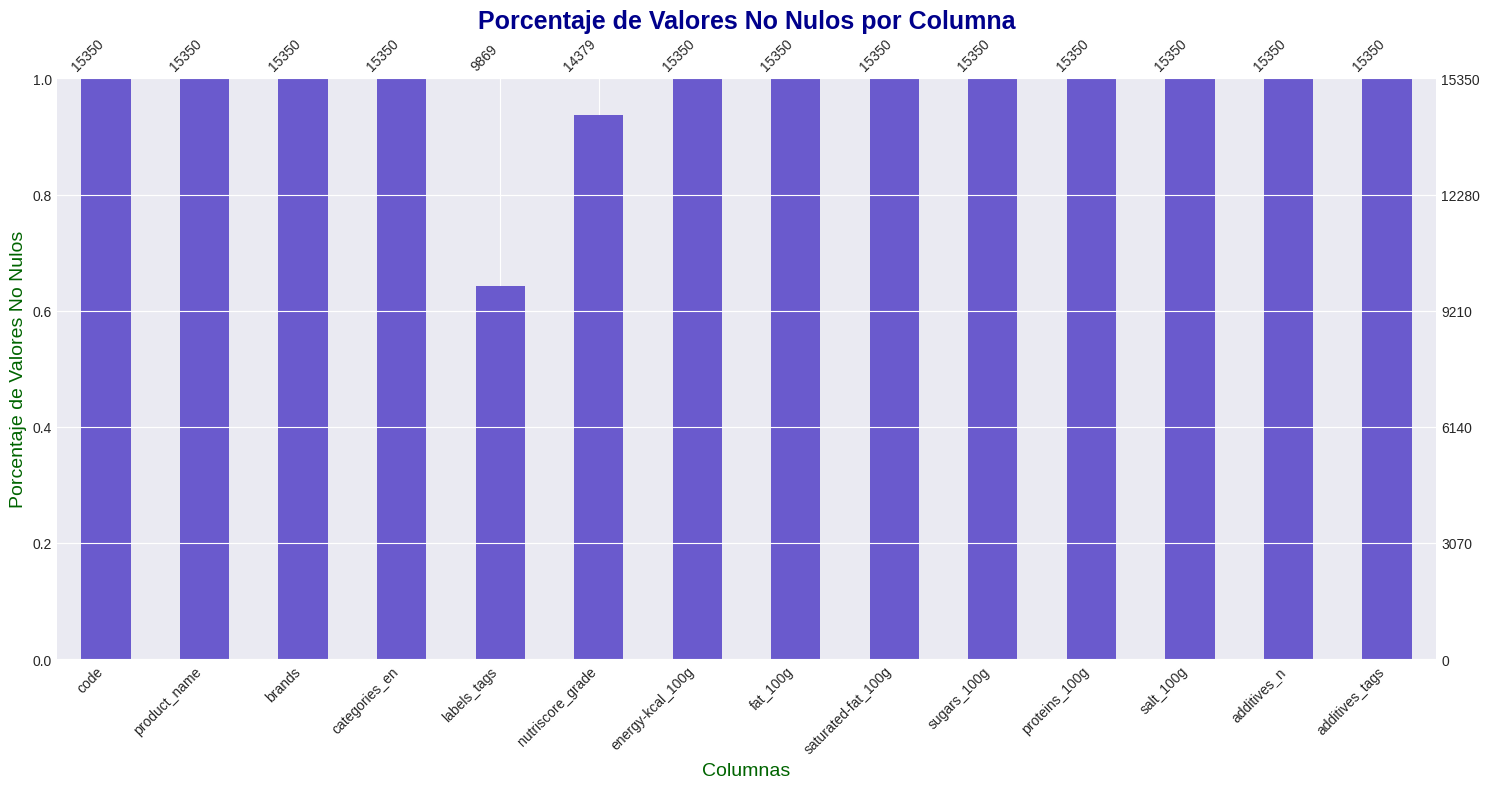

In [163]:

print("Análisis de Completitud de Columnas (Gráfico):")

plt.style.use('seaborn-v0_8-darkgrid')

ax = msno.bar(df_products_copy, figsize=(15, 8), color="#6A5ACD", fontsize=10, labels=True)

ax.set_title('Porcentaje de Valores No Nulos por Columna', fontsize=18, color='darkblue', fontweight='bold')
ax.set_xlabel('Columnas', fontsize=14, color='darkgreen')
ax.set_ylabel('Porcentaje de Valores No Nulos', fontsize=14, color='darkgreen')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**OUTLIERS**

He decidido hacer el metodo IQR para detectar outliers sin embargo en este caso no tiene mucho sentido debido a que esto depende de cada tipo de alimentos por tanto que  tengan valores altos no significa que estos esten mal todo lo contrario si no hubiese seria indicativo de que hay algo raro en el dataset, ejemplo de esto podria ser la sal pura o azucar que obviamente van a tener este valor mas alto etc... Aun asi creo que es interesante ver un poco mas de cerca todos estos valores.

Por otro lado destacar que anteriormente ya se ha echo un filtro para todos los valores anormales y que no tienen coherencia entre si

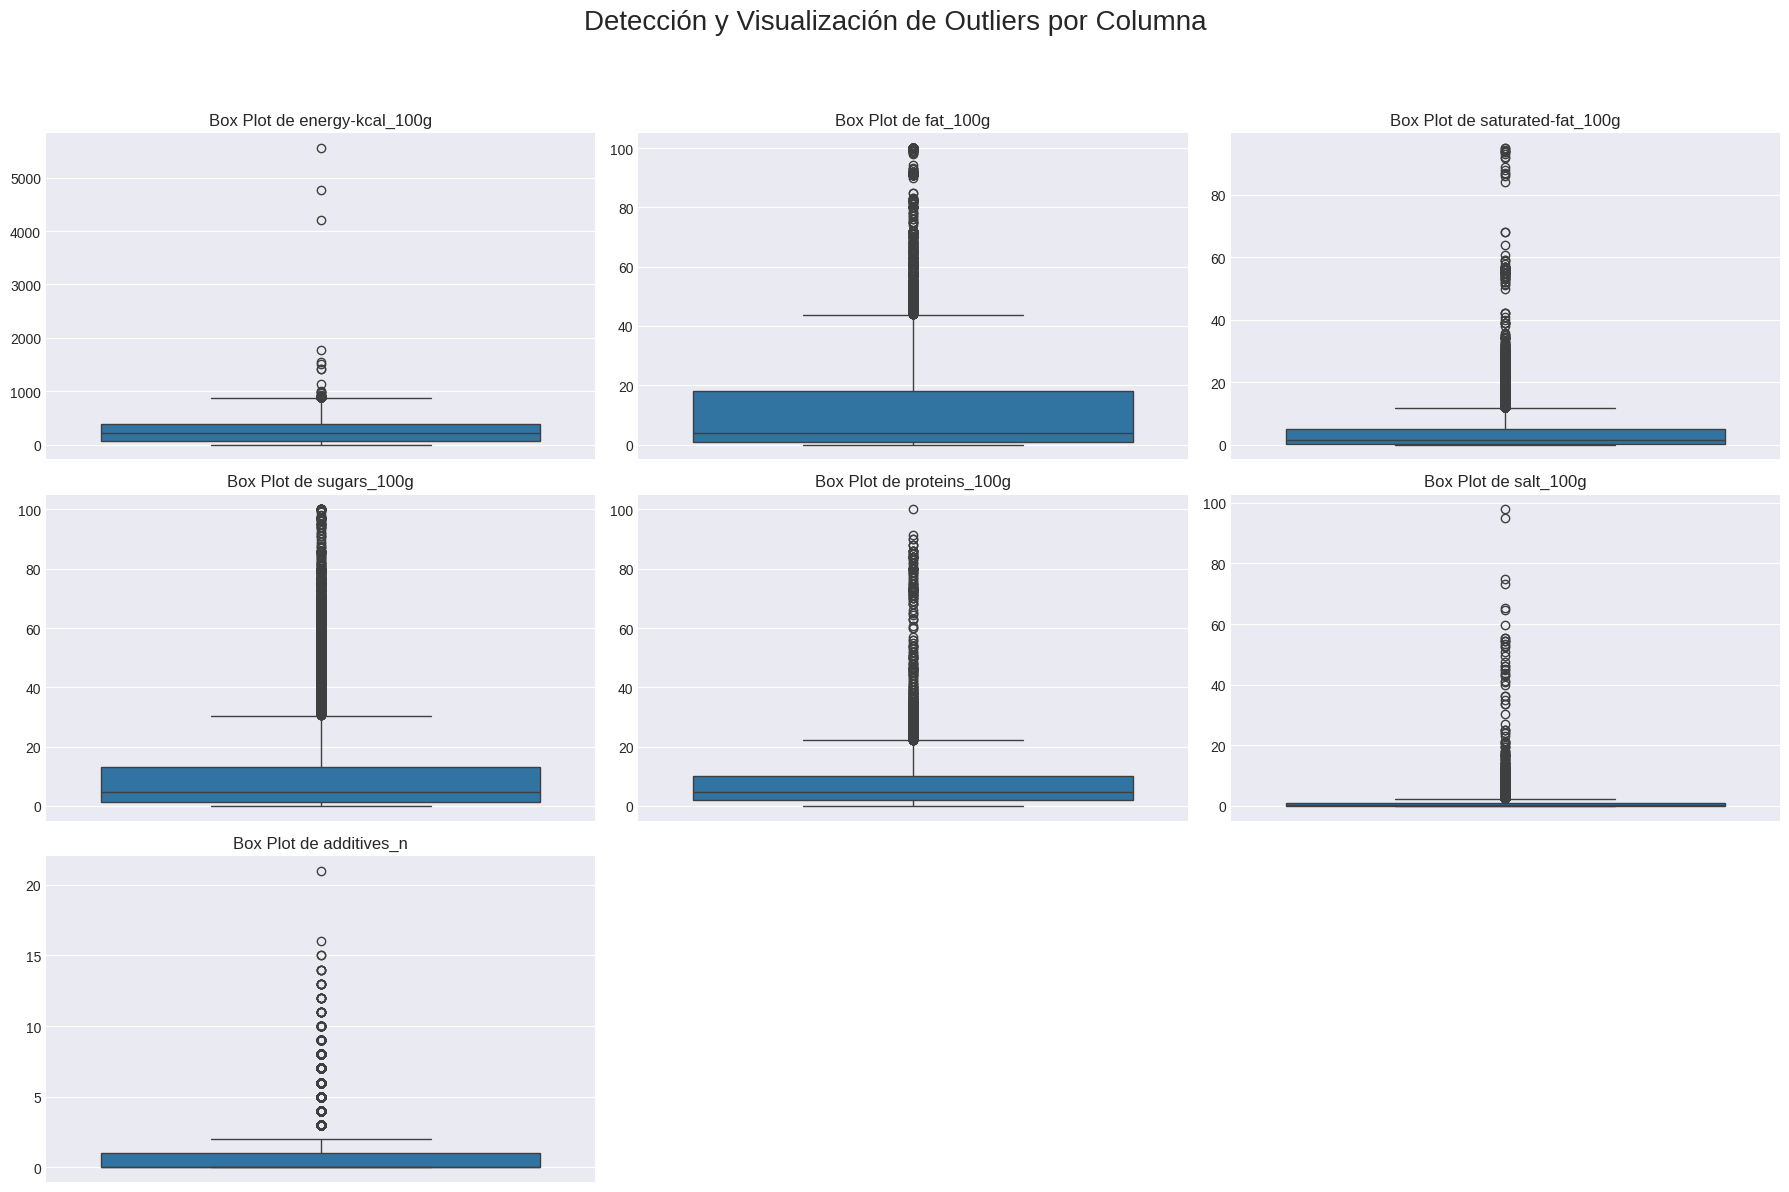


--- Conteo de Outliers Detectados (Método IQR)
Columna 'energy-kcal_100g': 117 outliers
Columna 'fat_100g': 819 outliers
Columna 'saturated-fat_100g': 1851 outliers
Columna 'sugars_100g': 1756 outliers
Columna 'proteins_100g': 1069 outliers
Columna 'salt_100g': 906 outliers
Columna 'additives_n': 2335 outliers


In [164]:


columnas_numericas = [
    'energy-kcal_100g',
    'fat_100g',
    'saturated-fat_100g',
    'sugars_100g',
    'proteins_100g',
    'salt_100g',
    'additives_n'
]

numero_outliners = {}

plt.figure(figsize=(18, 12))
plt.suptitle('Detección y Visualización de Outliers por Columna', fontsize=20, y=1.02)

for i, col in enumerate(columnas_numericas):
    if col in df_products_copy.columns and df_products_copy[col].dtype in ['float64', 'int64']:

        Q1 = df_products_copy[col].quantile(0.25)
        Q3 = df_products_copy[col].quantile(0.75)
        IQR = Q3 - Q1


        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR


        col_outliers = df_products_copy[(df_products_copy[col] < lower_bound) | (df_products_copy[col] > upper_bound)]
        numero_outliners[col] = len(col_outliers)


        plt.subplot(3, 3, i + 1)
        sns.boxplot(y=df_products_copy[col])
        plt.title(f'Box Plot de {col}')
        plt.ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\n--- Conteo de Outliers Detectados (Método IQR)")
for col, count in numero_outliners.items():
    print(f"Columna '{col}': {count} outliers")


Aqui podemos ver que hay diferentes outliers, aparentemente muchos de estos no daran problema en nuestro modelo, sin embargo la sal pura si lo hara por tanto tras varias pruebas se llega a la conclusión que lo que mejor se puede hacer es eliminarla.

In [165]:
print(f"Total de registros antes de filtrar por sal: {len(df_products_copy)}")
df_products_copy = df_products_copy[df_products_copy['salt_100g'] <= 25]
print(f"Total de registros antes de filtrar por sal: {len(df_products_copy)}")


Total de registros antes de filtrar por sal: 15350
Total de registros antes de filtrar por sal: 15314


**RESULTADOS LIMPIEZA ANTES VS DESPUES**

In [166]:
data = {
    'Parametro': ['Registros', 'Columnas', 'Nulos'],
    'df_products (Original)': [
        len(df_products),
        len(df_products.columns),
        df_products.isnull().sum().sum()
    ],
    'df_products_copy (Limpio)': [
        len(df_products_copy),
        len(df_products_copy.columns),
        df_products_copy.isnull().sum().sum()
    ]
}

df_comparison = pd.DataFrame(data)
display(df_comparison)


,Parametro,df_products (Original),df_products_copy (Limpio)
0,Registros,352707,15314
1,Columnas,209,14
2,Nulos,60038572,6415


**ESTADISTICAS DEL DATASET**

In [167]:
print("\n1️⃣ Información General:")
print(df_products_copy.info())
print("------------")
print("\n2️⃣ Estadísticas Descriptivas:")
display(df_products_copy.describe())
print("------------")
print("\n3️⃣ Top 10 Productos con mas aditivos:")
top_additives = df_products_copy.nlargest(10, 'additives_n')[['product_name', 'brands', 'additives_n', 'nutriscore_grade']]
display(top_additives)
print("------------")
print("\n4️⃣ Distribución del NutriScore:")
print(df_products_copy['nutriscore_grade'].value_counts().sort_index())
print("------------")
print("\n5️⃣ Marcas con mayor presencia:")
print(df_products_copy['brands'].value_counts().head(10))
print("------------")


1️⃣ Información General:
<class 'pandas.core.frame.DataFrame'>
Index: 15314 entries, 66 to 352005
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                15314 non-null  object 
 1   product_name        15314 non-null  object 
 2   brands              15314 non-null  object 
 3   categories_en       15314 non-null  object 
 4   labels_tags         9842 non-null   object 
 5   nutriscore_grade    14371 non-null  object 
 6   energy-kcal_100g    15314 non-null  float64
 7   fat_100g            15314 non-null  float64
 8   saturated-fat_100g  15314 non-null  float64
 9   sugars_100g         15314 non-null  float64
 10  proteins_100g       15314 non-null  float64
 11  salt_100g           15314 non-null  float64
 12  additives_n         15314 non-null  int64  
 13  additives_tags      15314 non-null  object 
dtypes: float64(6), int64(1), object(7)
memory usage: 1.8+ MB
None
------------

2️⃣

,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,salt_100g,additives_n
count,15314.000000,15314.000000,15314.000000,15314.000000,15314.000000,15314.000000,15314.000000
mean,251.252705,12.040034,4.170958,11.764413,7.646511,0.744336,0.961408
std,209.318358,17.345576,7.181554,17.058588,9.463930,1.508168,1.879130
min,0.063000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,70.000000,0.800000,0.200000,1.300000,1.900000,0.060000,0.000000
50%,212.000000,3.800000,1.300000,4.700000,4.800000,0.180000,0.000000
75%,393.000000,18.000000,4.800000,13.000000,10.000000,1.000000,1.000000
max,5555.000000,100.000000,95.000000,100.000000,100.000000,25.000000,21.000000


------------

3️⃣ Top 10 Productos con mas aditivos:


,product_name,brands,additives_n,nutriscore_grade
296824,sandwich york bacon y queso cremoso lm,lm sandwich,21,e
42828,pollo koreano,joviserrano,16,b
232560,sandwich atun,ñaming,15,c
349225,grilled chicken flavour,yum yum,15,e
75700,party fizz - assortiment de confiseries gelifiees,lutti,14,e
179515,firgas mango fresh,firgas,14,b
179524,flautas de bacon y queso,hacendado,14,e
190754,pantera rosa,bimbo,14,e
21540,deluxe,deluxe villa gusto,13,a
22289,dessert with lemon,deluxe,13,e


------------

4️⃣ Distribución del NutriScore:
nutriscore_grade
a    2282
b    2027
c    3712
d    3174
e    3176
Name: count, dtype: int64
------------

5️⃣ Marcas con mayor presencia:
brands
carrefour     1565
hacendado      681
danone         299
dia            270
nestle         256
auchan         209
milbona        191
carrefour      170
eroski         138
prozis         109
Name: count, dtype: int64
------------


GRAFICOS ADICIONALES INTERESANTES

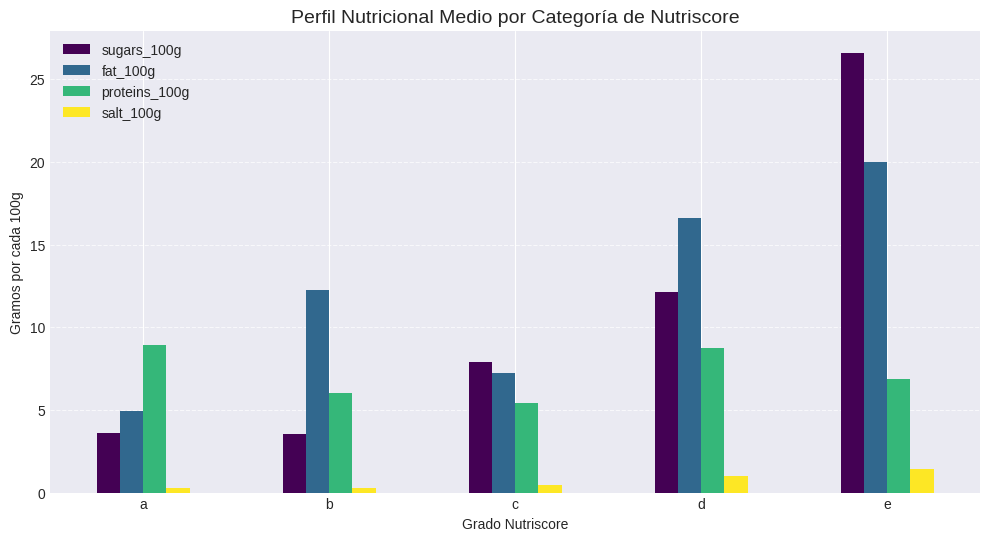

In [168]:
df_media_por_gramo = df_products_copy.groupby('nutriscore_grade')[['sugars_100g', 'fat_100g', 'proteins_100g', 'salt_100g']].mean()

df_media_por_gramo.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Perfil Nutricional Medio por Categoría de Nutriscore', fontsize=14)
plt.ylabel('Gramos por cada 100g')
plt.xlabel('Grado Nutriscore')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En este grafico podemos ver como los productos con nutrisocre a contiene mas proteina y menos azucares, grasas y sal que los demas productos siendo mas sanos.

En cuanto a los que tienen nutiscore b es muy interesante destacar como este tiene una cantidad mas alta de grasas en comparacion con el c diferenciandose principalmente por el azucar.

Por ultimo podemos ver como el nutriscore d y e en comparacion con los demas tienen una gran cantidad de azucares, grasas y sal

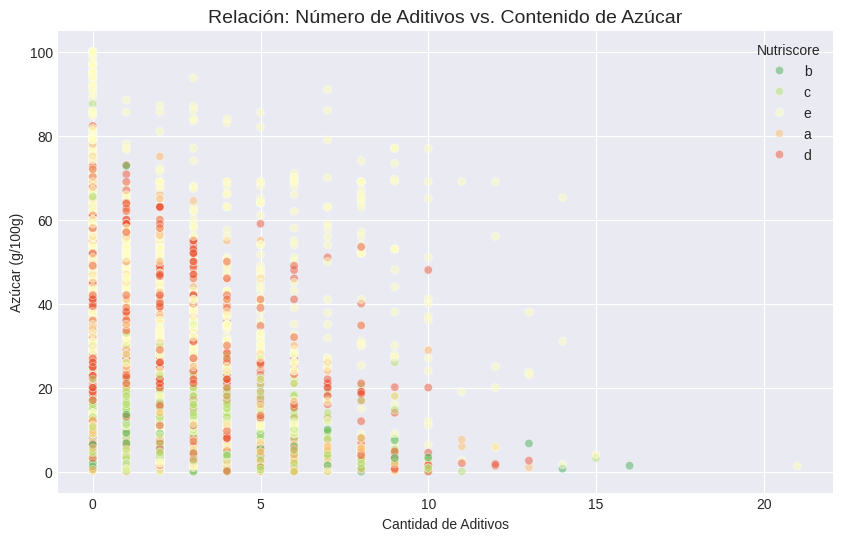

In [169]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_products_copy, x='additives_n', y='sugars_100g', hue='nutriscore_grade',
                palette='RdYlGn_r', alpha=0.5)
plt.title('Relación: Número de Aditivos vs. Contenido de Azúcar', fontsize=14)
plt.xlabel('Cantidad de Aditivos')
plt.ylabel('Azúcar (g/100g)')
plt.legend(title='Nutriscore')
plt.show()

En este grafico se puede apreciar que en muchos de estos productos a medida que tienen menos azucar mas aditivos tienen

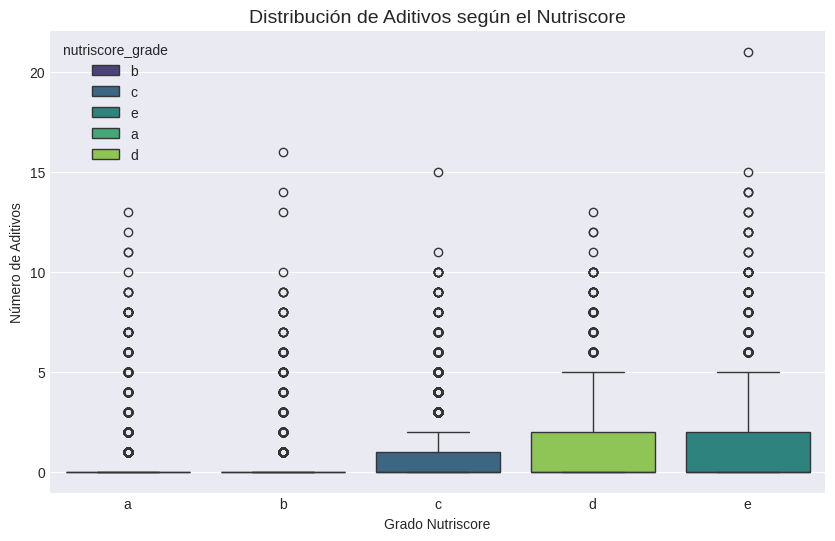

In [170]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nutriscore_grade', y='additives_n', data=df_products_copy, palette='viridis', order=['a', 'b', 'c', 'd', 'e'],hue='nutriscore_grade')
plt.title('Distribución de Aditivos según el Nutriscore', fontsize=14)
plt.xlabel('Grado Nutriscore')
plt.ylabel('Número de Aditivos')
plt.show()

En este g

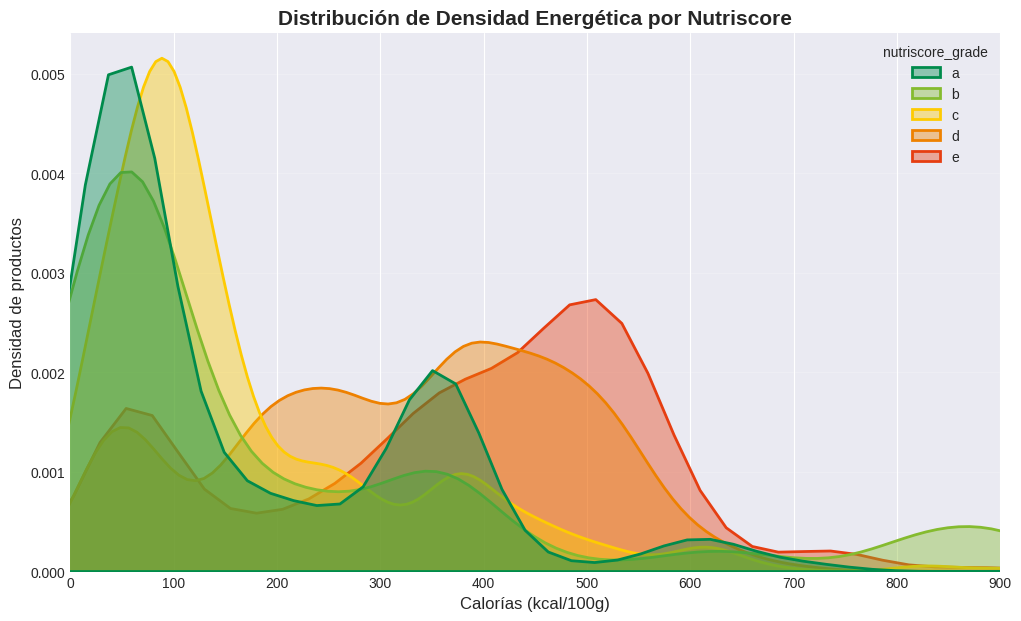

In [171]:
plt.figure(figsize=(12, 7))
sns.kdeplot(
    data=df_products_copy,
    x='energy-kcal_100g',
    hue='nutriscore_grade',
    hue_order=['a', 'b', 'c', 'd', 'e'],
    palette=['#008b4c', '#85bb2f', '#fecb02', '#ee8100', '#e63e11'],
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2
)

plt.title('Distribución de Densidad Energética por Nutriscore', fontsize=15, fontweight='bold')
plt.xlabel('Calorías (kcal/100g)', fontsize=12)
plt.ylabel('Densidad de productos', fontsize=12)
plt.xlim(0, 900)
plt.grid(axis='y', alpha=0.2)

plt.show()

# **CREACIÓN DEL MODELO**

en esta parte nos centraremos en todo lo relacionado a preparar los datos para asegurarnos que el modelo sea lo más optimo posible

**FEATURE ENGINEERING**

Para este paso vamos a definir varias columnas binarias, en las cuales gracias a estas el modelo podrá interepretar datos relacionados con las etiquetas, una de estas estara relacionada con los productos que llevan bio o algo por el estilo, otra con los naturales y otra con los veganos.
Aqui el problema que encontramos es la grancantidad de etiquetas que podemos encontrar por tanto lo mas util sera mirar el dataset por encima e intentar poner todas las posibles.

In [172]:
df_products_model=df_products_copy.copy()

In [173]:
print(df_products_model[['labels_tags']].head(50).to_string())

                                                                                                                                                                                                                                          labels_tags
66                                                                                                                                                                                                                                                NaN
67                                                                                                                                                                                                                                                NaN
78                                                                                                                                                                                                                                                NaN
87              

In [174]:
array_bio = [
    'bio', 'eco', 'organic', 'organico', 'ecologico', 'biologique', 'biologico',
    'agricultura ecologica', 'sustentable', 'sostenible', 'green', 'eco-friendly',
    'eu-organic', 'usda-organic', 'procedente de agricultura', 'es-eco', 'nl-bio',
    'agriculture biologique', 'bio-organic', 'ecocert', 'rainforest alliance',
    'huella de carbono', 'carbon neutral', 'carbon-footprint', 'cultivo sostenible',
    'respetuoso', 'planeta', 'proximidad', 'km0', 'kilometro 0', 'envirobox'
]

array_natural = [
    'natural', 'naturel', '100% natural', '100-natural', 'origen natural',
    'ingredientes naturales', 'puro', 'pure', 'artesano', 'artesanal',
    'tradicional', 'casero', 'sin aditivos', 'no additives', 'no-additives',
    'sin conservantes', 'sin colorantes', 'no preservatives', 'no colorings',
    'no-preservatives', 'no-colorings', 'raw', 'crudo', 'antigua receta',
    'como hecho en casa', 'sin refinar', 'unrefined', 'naturalmente',
    'naturally', 'autentico', 'real food', 'clean label', 'verified'
]

array_vegan = [
    'vegan', 'vegano', 'vegetarian', 'vegetariano', 'v-label', 'plant-based',
    '100% vegetal', 'base vegetal', 'cruelty-free', 'no animal testing',
    'sin huevo', 'sin leche', 'sin lactosa', 'sin productos animales',
    'egg-free', 'dairy-free', 'no animal ingredients', 'apto para veganos',
    'proteina vegetal', 'vegetal protein', 'the-vegan-society', 'vegan-action',
    'no-lactose', 'no-soy'
]

array_light = [
    '0%', 'zero', 'cero', 'light', 'diet', 'sin azucar', 'no sugar', 'no-sugar',
    'sin azucares añadidos', 'no added sugar', 'bajo en grasa', 'low fat',
    'low-fat', 'reduced fat', 'reduced-sugar', 'reducido en', 'menos calorias',
    'low calories', 'sin añadidos', 'sugar free', 'fat free', '0% grasa',
    '0% azucares', '0% azucar', 'sin azucares', 'stevia', 'edulcorado',
    'sweetened', 'low-or-no-sugar', 'naturally-fat-free'
]

array_proteina = [
    'protein', 'proteina', 'high protein', 'alto en proteina', 'plus protein',
    'fuente de proteina', 'enriquecido con proteina', 'musculo', 'sport',
    'whey', 'proteinas', 'pro', 'performance', 'isolada', 'isolate',
    'aminoacidos', 'bcaa', 'energy'
]

array_salud = [
    'equilibrado', 'nutritivo', 'saludable', 'healthy', 'bienestar', 'wellness',
    'vital', 'fitness', 'linea', 'silueta', 'cuidacol', 'digestivo', 'digestive',
    'superfood', 'superalimento', 'probioticos', 'prebioticos', 'defensas',
    'inmunitario', 'rico en fibra', 'high fiber', 'omega 3', 'antioxidante',
    'detox', 'limpia', 'purifica', 'nutritional'
]

array_riesgo_alto = [
    'e102', 'e104', 'e110', 'e122', 'e124', 'e129',
    'e127', 'e131', 'e132', 'e142', 'e151', 'e154', 'e155',
    'e210', 'e211', 'e212', 'e213', 'e214', 'e215',
    'e216', 'e217', 'e218', 'e219',
    'e249', 'e250', 'e251', 'e252',
    'e951', 'e952', 'e954', 'e961',
    'e320', 'e321',
    'e171', 'e173', 'e284', 'e285', 'e512',
    'e623', 'e626', 'e627', 'e628', 'e629',
    'e630', 'e631', 'e635',
]

array_riesgo_medio = [
    'e100', 'e101', 'e120', 'e133',
    'e150a', 'e150b', 'e150c', 'e150d', 'e160b',
    'e200', 'e202', 'e203',
    'e220', 'e221', 'e222', 'e223', 'e224', 'e225', 'e226', 'e227', 'e228',
    'e270',
    'e950', 'e953', 'e955', 'e960', 'e965', 'e966', 'e967', 'e968',
    'e620', 'e621', 'e622',
    'e407', 'e412', 'e415',
    'e433', 'e434', 'e435', 'e436',
    'e450', 'e451', 'e452',
    'e460', 'e461', 'e466',
    'e471', 'e472e', 'e481', 'e482',
    'e310', 'e311', 'e312', 'e316',
    'e338', 'e339', 'e340', 'e341',
    'e1422', 'e1442',
]


In [175]:
patron_bio = '|'.join(array_bio)
patron_natural = '|'.join(array_natural)
patron_vegan = '|'.join(array_vegan)
patron_light = '|'.join(array_light)
patron_proteina = '|'.join(array_proteina)
patron_salud = '|'.join(array_salud)

In [176]:
def detectar_marketing(df, patron):
    en_nombre = df['product_name'].str.contains(patron, case=False, na=False, regex=True)
    en_labels = df['labels_tags'].str.contains(patron, case=False, na=False, regex=True)
    return (en_nombre | en_labels).astype(int)


def detectar_aditivos_nocivos(tags):
    if pd.isna(tags): return 0
    tags = str(tags).lower()
    score = (sum(3 for a in array_riesgo_alto if a in tags) +
             sum(1 for a in array_riesgo_medio if a in tags))
    return score

In [177]:
df_products_model['aditivos_score'] = df_products_model['additives_tags'].apply(detectar_aditivos_nocivos)

In [178]:
df_products_model['f_bio'] = detectar_marketing(df_products_model, patron_bio)
df_products_model['f_natural'] = detectar_marketing(df_products_model, patron_natural)
df_products_model['f_vegan'] = detectar_marketing(df_products_model, patron_vegan)
df_products_model['f_light'] = detectar_marketing(df_products_model, patron_light)
df_products_model['f_proteina'] = detectar_marketing(df_products_model, patron_proteina)
df_products_model['f_salud'] = detectar_marketing(df_products_model, patron_salud)

print(" RESULTADOS DEL ESCANEO DE BINARIOS")
print("="*40)
columnas_mkt = ['f_bio', 'f_natural', 'f_vegan', 'f_light', 'f_proteina', 'f_salud']
for col in columnas_mkt:
    total = df_products_model[col].sum()
    print(f" {col:12} : {total} productos encontrados")

 RESULTADOS DEL ESCANEO DE BINARIOS
 f_bio        : 5271 productos encontrados
 f_natural    : 2285 productos encontrados
 f_vegan      : 2043 productos encontrados
 f_light      : 1028 productos encontrados
 f_proteina   : 831 productos encontrados
 f_salud      : 123 productos encontrados


In [179]:
print(df_products_model.head(50).to_string())

             code                                            product_name                                        brands                         categories_en                                                                                                                                                                                                                                      labels_tags nutriscore_grade  energy-kcal_100g   fat_100g  saturated-fat_100g  sugars_100g  proteins_100g  salt_100g  additives_n                            additives_tags  aditivos_score  f_bio  f_natural  f_vegan  f_light  f_proteina  f_salud
66           1065                                   boisson à l'aloe vera                                     herbalife       plant-based foods and beverages                                                                                                                                                                                                                   

**ANÁLISIS DE CORRELLACIÓN**

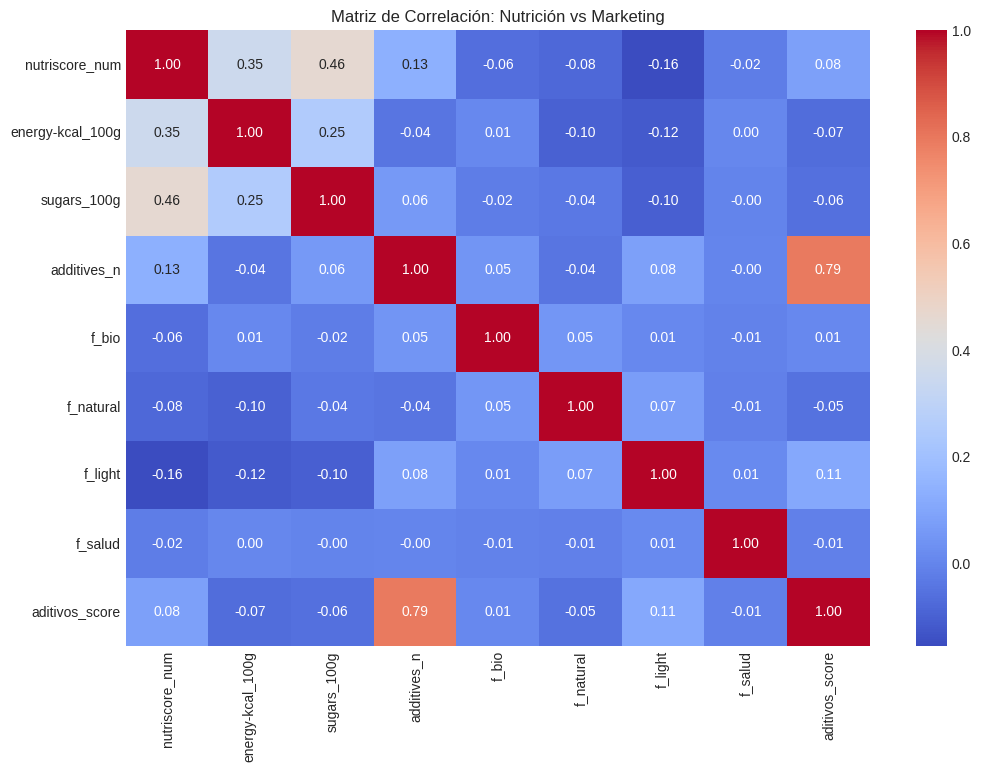

In [180]:
mapa_nutri = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
df_products_model['nutriscore_num'] = df_products_model['nutriscore_grade'].map(mapa_nutri)


cols_analisis = ['nutriscore_num', 'energy-kcal_100g', 'sugars_100g', 'additives_n',
                 'f_bio', 'f_natural', 'f_light', 'f_salud','aditivos_score']

corr = df_products_model[cols_analisis].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: Nutrición vs Marketing")
plt.show()

En la matriz de correlación podemos observar que aunque un producto sea bio o natural no tiene apenas relacion con la calidad nutricional(nutriscore). Esto sugiere que se hace uso de estos terminos como estrategia de marketing que no suponene una mejora. Por otro lado con los productos que se suponen que tienen etiquetas como que tienen mayor proteina tiene muchois de ellos trampa porque tambien aumentan los numeros de aditivos y contienen peores notas nutricionales.

**K-MEANS**

He elegido hacer uso de K-Means debido a la naturaleza de los datos, estos al ser una gran cantidad de datos he pensado que era la mejor forma de segmentar y ver de forma mas directa y cambiante los resultados y si estos no se adaptaban a lo buscado poder modificarlos de forma rapida gracias a su velocidad y escalabilidad.

Muy importante para nuestro modelo vamos a separar las variables numericas de las binarias por que si no se va a escalar mal.

In [181]:
cols_num = [
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'sugars_100g', 'proteins_100g', 'salt_100g',
]

cols_bin = [
    'f_bio', 'f_natural', 'f_vegan', 'f_light', 'f_proteina', 'f_salud'
]

df_product_train=df_products_model.copy()


**ESCALADO**

Muy importante esta parte, anteriormente el modelo de datos no era concluyente debido a que no se sesgaba de una forma claro ya que he metido columnas binarias las cuales ya estan escaladas en el escalado y tambien porque el StandardScaler es sensible a los outliners que en este caso son productos reales verdaderos con informacion bien puesto pero son Outliners, por tanto se usara el RobustScale ya que en vez de la media usa la mediana.

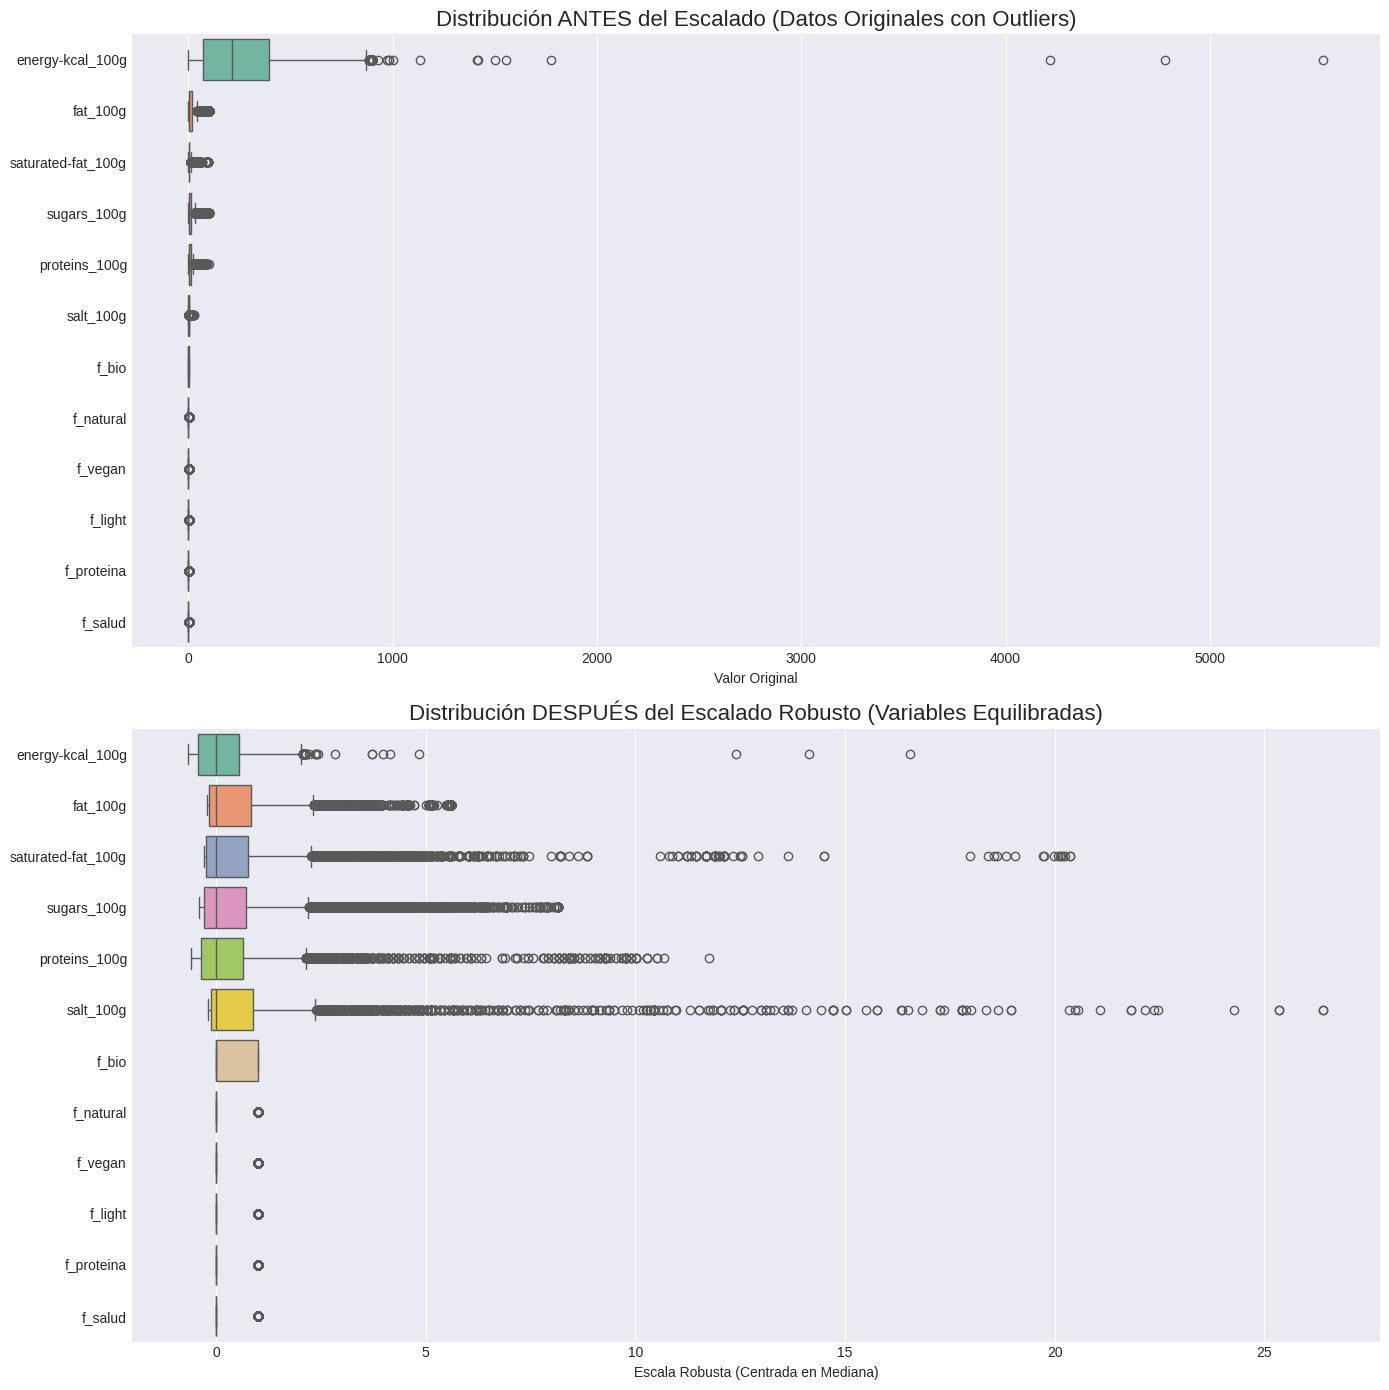

In [182]:
robust_scaler = RobustScaler()
df_product_train_scaled=robust_scaler.fit_transform(df_product_train[cols_num])
df_num_scaled = pd.DataFrame(df_product_train_scaled, columns=cols_num)

df_visualizacion = pd.concat([df_num_scaled, df_product_train[cols_bin].reset_index(drop=True)], axis=1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))


sns.boxplot(data=df_product_train[cols_num + cols_bin], ax=ax1, orient='h', palette='Set2')
ax1.set_title('Distribución ANTES del Escalado (Datos Originales con Outliers)', fontsize=16)
ax1.set_xlabel('Valor Original')


sns.boxplot(data=df_visualizacion, ax=ax2, orient='h', palette='Set2')
ax2.set_title('Distribución DESPUÉS del Escalado Robusto (Variables Equilibradas)', fontsize=16)
ax2.set_xlabel('Escala Robusta (Centrada en Mediana)')

plt.tight_layout()
plt.show()



In [183]:
print('Estadísticas ANTES del Escalado (Valores Originales)')

print(df_product_train[cols_num].describe().loc[['mean', 'std', 'min', '50%', 'max']].round(2))

print('\n' + '-'*60 + '\n')

print('Estadísticas DESPUÉS del Escalado Robusto (Centrado en Mediana)')
print(df_visualizacion[cols_num].describe().loc[['mean', 'std', 'min', '50%', 'max']].round(2))

Estadísticas ANTES del Escalado (Valores Originales)
      energy-kcal_100g  fat_100g  saturated-fat_100g  sugars_100g  \
mean            251.25     12.04                4.17        11.76   
std             209.32     17.35                7.18        17.06   
min               0.06      0.00                0.00         0.00   
50%             212.00      3.80                1.30         4.70   
max            5555.00    100.00               95.00       100.00   

      proteins_100g  salt_100g  
mean           7.65       0.74  
std            9.46       1.51  
min            0.00       0.00  
50%            4.80       0.18  
max          100.00      25.00  

------------------------------------------------------------

Estadísticas DESPUÉS del Escalado Robusto (Centrado en Mediana)
      energy-kcal_100g  fat_100g  saturated-fat_100g  sugars_100g  \
mean              0.12      0.48                0.62         0.60   
std               0.65      1.01                1.56         1.46   


**ELBOW METHOD Y SILHOUETTE**

En este caso vamos a utilizar estos dos metodos para decidir el numero de cluster a utilizar, por un lado el metodo del codo se fija en que tan cerca estan los puntos del centro de sus propio grupo, a mas cluster mas bajo es el porcentaje por eso hay que buscar un punto medio, mientras que el silhouette mide si los grupos de puntos estan bien separados, si se encuentra mal alto mas separado estara.

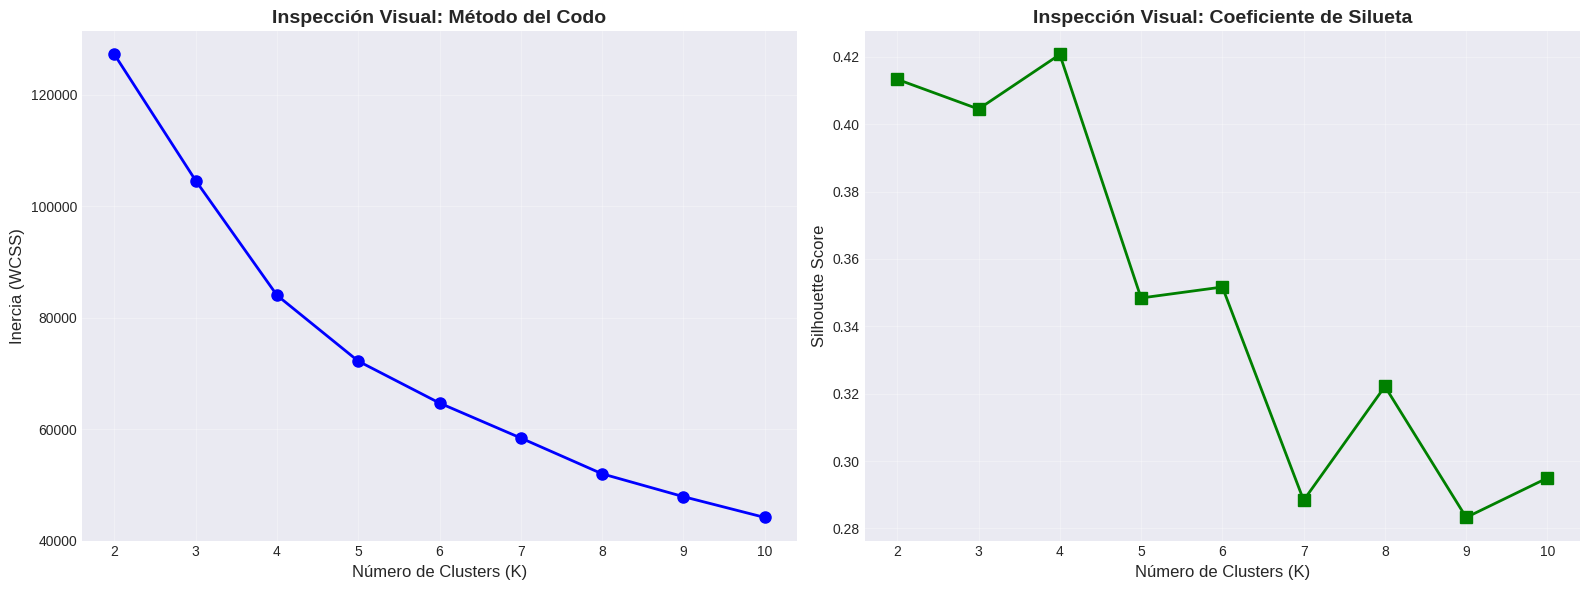


--- TABLA DE DATOS PARA DECISIÓN FINAL ---
 K Inercia Silhouette
 2  127212     0.4133
 3  104577     0.4045
 4   84003     0.4207
 5   72188     0.3484
 6   64671     0.3517
 7   58393     0.2883
 8   51973     0.3222
 9   47875     0.2833
10   44146     0.2950


In [184]:


X = df_visualizacion

inercias = []
silhouette_scores = []
K_range = range(2, 11)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(K_range, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Inspección Visual: Método del Codo', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)


axes[1].plot(K_range, silhouette_scores, 'gs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Inspección Visual: Coeficiente de Silueta', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


tabla_metrics = pd.DataFrame({
    'K': list(K_range),
    'Inercia': [f'{v:.0f}' for v in inercias],
    'Silhouette': [f'{v:.4f}' for v in silhouette_scores]
})

print('\n--- TABLA DE DATOS PARA DECISIÓN FINAL ---')
print(tabla_metrics.to_string(index=False))

Como se puede observar el Silhouette nos dice que lo mejor estaria entre 6 o 5 ya que los grupos estan bastante bien separados y apenas hay diferencia entre ellos, por otro lado la inercia hace que los grupos esten mas definidos y mas juntos por tanto en este trabajo voy a elegir 6 clusters por que va a aparecer un grupo mas que puede ser de gran interes.

**ENTRENAMIENTO Y PERFILADO**

In [185]:

k_final = 6


kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_product_train['cluster'] = kmeans_final.fit_predict(df_visualizacion)


cols_analisis = [
    'energy-kcal_100g', 'fat_100g', 'sugars_100g', 'salt_100g',
     'f_bio', 'f_natural', 'f_salud', 'cluster'
]

perfiles = df_product_train[cols_analisis].groupby('cluster').mean().round(2)

print(f"✅ Modelo entrenado con K={k_final}")
print("\nPERFILES DE LOS CLUSTERS (Valores Medios Reales)")
print(perfiles)


print("\nTAMAÑO DE LOS GRUPOS")
print(df_product_train['cluster'].value_counts().sort_index())

✅ Modelo entrenado con K=6

PERFILES DE LOS CLUSTERS (Valores Medios Reales)
         energy-kcal_100g  fat_100g  sugars_100g  salt_100g  f_bio  f_natural  \
cluster                                                                         
0                  371.44      8.24        57.12       0.24   0.33       0.12   
1                  142.58      3.75         7.33       0.32   0.35       0.17   
2                  227.47      8.16         8.63      11.90   0.32       0.10   
3                  745.16     82.19         1.43       0.44   0.40       0.21   
4                  342.76     18.74         3.03       1.77   0.32       0.11   
5                  510.04     38.86        17.25       0.59   0.37       0.12   

         f_salud  
cluster           
0           0.00  
1           0.01  
2           0.00  
3           0.00  
4           0.01  
5           0.01  

TAMAÑO DE LOS GRUPOS
cluster
0    1213
1    8936
2     157
3      75
4    2897
5    2036
Name: count, dtype: int64


**ANALISIS DE CENTROIDES**

--- CENTROIDES EN ESCALA ORIGINAL (Valores Reales) ---


,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,salt_100g,f_bio,f_natural,f_vegan,f_light,f_proteina,f_salud
Cluster 0,371.44,8.24,2.89,57.12,3.98,0.24,0.33,0.12,0.13,0.01,0.03,0.00
Cluster 1,142.59,3.75,1.23,7.33,4.40,0.32,0.35,0.17,0.13,0.09,0.05,0.01
Cluster 2,227.47,8.16,1.46,8.63,11.25,11.90,0.32,0.10,0.22,0.04,0.03,0.00
Cluster 3,745.16,82.19,62.44,1.43,1.19,0.44,0.40,0.21,0.11,0.04,0.03,-0.00
Cluster 4,342.65,18.73,4.24,3.03,18.05,1.77,0.32,0.11,0.17,0.06,0.10,0.01
Cluster 5,510.04,38.86,15.79,17.25,9.23,0.59,0.37,0.12,0.10,0.04,0.03,0.01


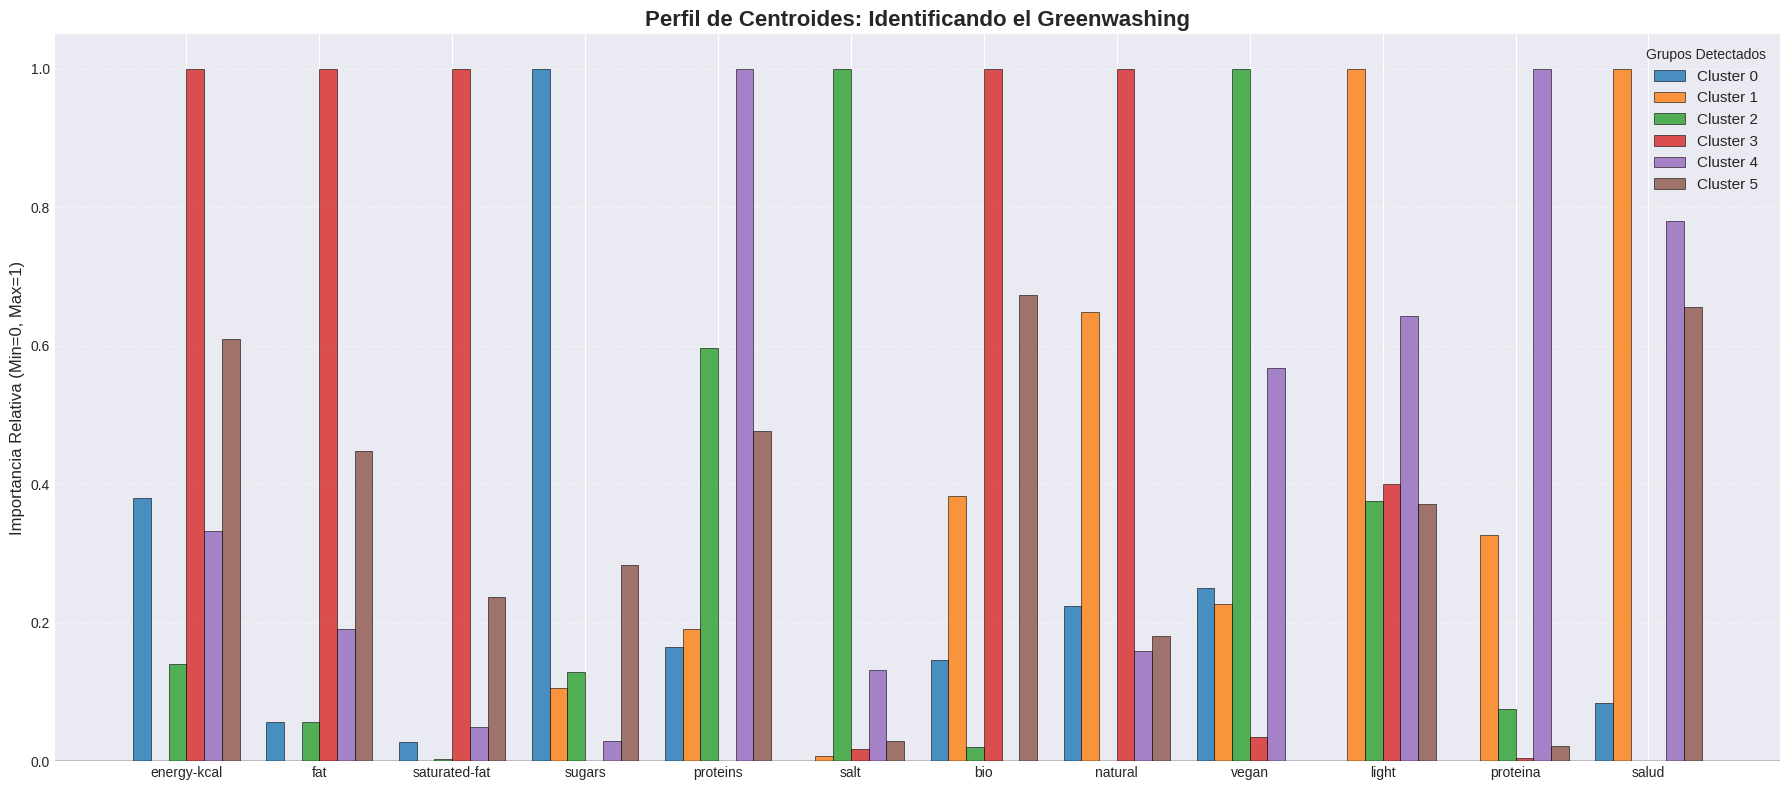

In [186]:
centroides_modelo = kmeans_final.cluster_centers_

n_nums = len(cols_num)
centroides_nums = centroides_modelo[:, :n_nums]
centroides_flags = centroides_modelo[:, n_nums:]

centroides_nums_rescaled = robust_scaler.inverse_transform(centroides_nums)

centroides_finales = np.hstack([centroides_nums_rescaled, centroides_flags])

columnas_totales = cols_num + cols_bin
df_centroides = pd.DataFrame(centroides_finales, columns=columnas_totales)
df_centroides.index = [f'Cluster {i}' for i in range(k_final)]

print('--- CENTROIDES EN ESCALA ORIGINAL (Valores Reales) ---')
display(df_centroides.round(2))

fig, ax = plt.subplots(figsize=(18, 8))

df_centroides_norm = (df_centroides - df_centroides.min()) / (df_centroides.max() - df_centroides.min())

colors_cluster = plt.cm.tab10.colors[:k_final]

x = np.arange(len(columnas_totales))
width = 0.80 / k_final

for i, (cluster, color) in enumerate(zip(df_centroides_norm.index, colors_cluster)):
    ax.bar(x + i * width, df_centroides_norm.loc[cluster], width,
           label=cluster, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width * (k_final / 2 - 0.5))

nombres_eje = [f.replace('_100g', '').replace('f_', '').replace('_', '\n') for f in columnas_totales]
ax.set_xticklabels(nombres_eje, fontsize=10, rotation=0)

ax.set_ylabel('Importancia Relativa (Min=0, Max=1)', fontsize=12)
ax.set_title('Perfil de Centroides: Identificando el Greenwashing', fontsize=16, fontweight='bold')
ax.legend(title="Grupos Detectados", fontsize=11, loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

En este caso se han delimitado 6 clusters.

En cuanto al cluster 0, podemos ver que son productos que tienen una cantidad de azúcar brutal (media de 57g), donde el marketing falso suele pegar fuerte con etiquetas de "Natural" para ocultar que son básicamente dulces.

En cuanto al cluster 1, parece que está más relacionado con productos realmente sanos o de base, con niveles bajos de todo y sin esas campañas de marketing tan engañosas, siendo el grupo más equilibrado.

En cuanto al cluster 2, es donde vemos productos con una cantidad de sal extrema (casi 12g). Aquí el marketing se centra en lo "Tradicional" o "Artesano" para que no mires el exceso de sodio que llevan.

En cuanto al cluster 3, son productos con una cantidad de grasa tan extrema que el modelo los ha tenido que separar. Son casos muy específicos de lípidos puros donde el marketing suele ser muy agresivo para que parezcan otra cosa.

En cuanto al cluster 4, vemos productos con mucha proteína pero que nos la cuelan con niveles moderados de grasa y sal. Aquí el marketing suele tirar de lo "Fit" o "Proteico" para disfrazar el perfil procesado.

En cuanto al cluster 5, se nota que son productos muy procesados y energéticos (tipo snacks o bollería industrial) que mezclan de todo: grasa y azúcar en niveles muy altos, lo que indica un perfil nutricional bastante malo.

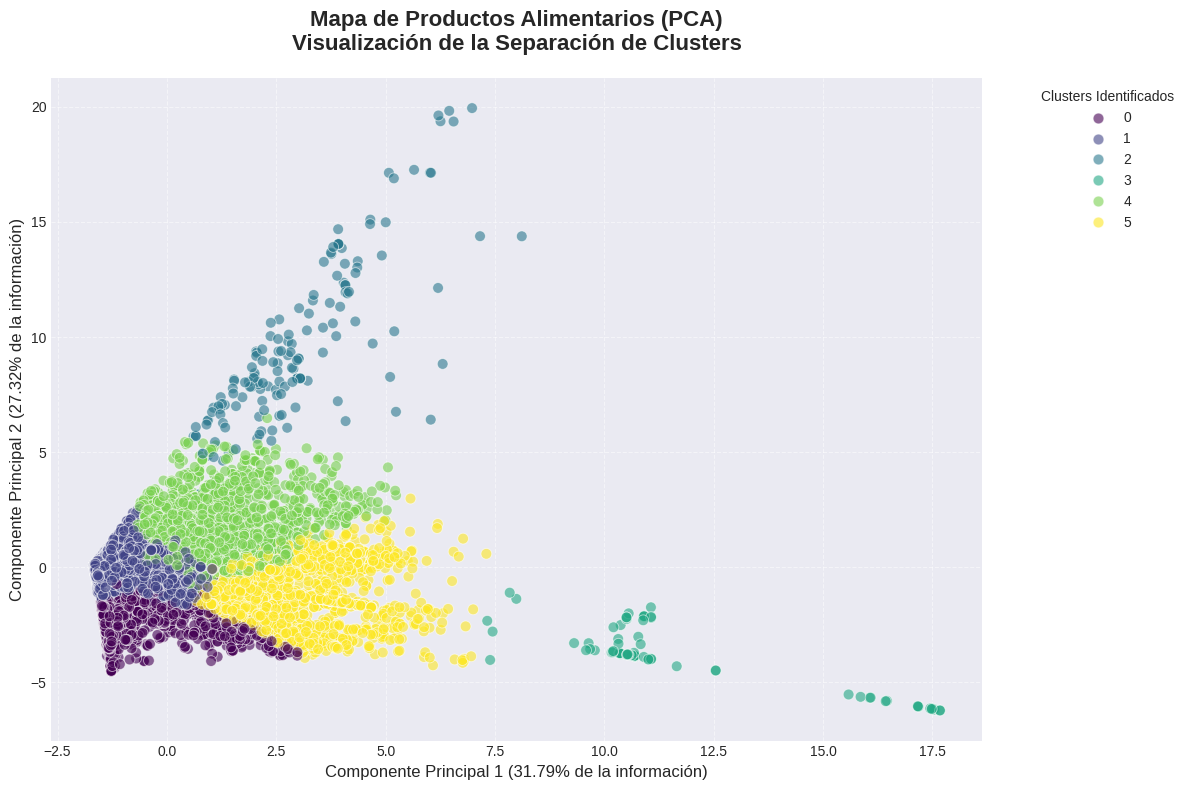

--- PESO DE CADA VARIABLE EN LOS EJES (Loadings) ---
Este análisis explica qué define la posición de los productos en el mapa:
                         PC1       PC2
saturated-fat_100g  0.776273 -0.267266
fat_100g            0.451214 -0.093391
salt_100g           0.291635  0.762792
energy-kcal_100g    0.242315 -0.082130
proteins_100g       0.222955  0.234968
sugars_100g         0.010005 -0.525094
f_bio               0.005106 -0.002109
f_vegan            -0.000317  0.014485
f_proteina         -0.000415  0.008234
f_salud            -0.001027  0.000077
f_light            -0.009797  0.005857
f_natural          -0.010327  0.000215


In [187]:
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(df_visualizacion)


varianza = pca.explained_variance_ratio_ * 100


df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_product_train['cluster'].values


plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=df_pca,
    palette='viridis',
    alpha=0.6,
    edgecolor='w',
    s=60
)


plt.title('Mapa de Productos Alimentarios (PCA)\nVisualización de la Separación de Clusters', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'Componente Principal 1 ({varianza[0]:.2f}% de la información)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({varianza[1]:.2f}% de la información)', fontsize=12)

plt.legend(title='Clusters Identificados', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=columnas_totales
)

print("--- PESO DE CADA VARIABLE EN LOS EJES (Loadings) ---")
print("Este análisis explica qué define la posición de los productos en el mapa:")
print(loadings.sort_values(by='PC1', ascending=False))

# CONCLUSION

Para poder usar nuestro modelo tendremos que escalar los datos que vamos a usar para hacer el analisis por que si no este no lo entiende

In [188]:
df_products_analisis=df_products_model.copy()

In [189]:

X_nutri_scaled = robust_scaler.transform(df_products_analisis[cols_num])

X_nutri_df = pd.DataFrame(X_nutri_scaled, columns=cols_num, index=df_products_analisis.index)


X_final_para_modelo = pd.concat([X_nutri_df, df_products_analisis[cols_bin]], axis=1)

df_products_analisis['cluster_nutricional'] = kmeans_final.predict(X_final_para_modelo)

In [190]:
nombres_cluster = {
    0: 'Ultraprocesados Azucarados',
    1: 'Base Saludable / Bajos en Calorías',
    2: 'Concentrados Salinos',
    3: 'Grasas y Aceites',
    4: 'Proteicos',
    5: 'Ultraprocesados Energéticos Mixtos'
}
df_products_analisis['cluster_nombre'] = df_products_analisis['cluster_nutricional'].map(nombres_cluster)

In [191]:
print("📊 PRODUCTOS POR CLUSTER:")
print(df_products_analisis['cluster_nutricional'].value_counts())

print("\n🏷️ PRODUCTOS POR NOMBRE DE CLUSTER:")
print(df_products_analisis['cluster_nombre'].value_counts())

📊 PRODUCTOS POR CLUSTER:
cluster_nutricional
1    8936
4    2897
5    2036
0    1213
2     157
3      75
Name: count, dtype: int64

🏷️ PRODUCTOS POR NOMBRE DE CLUSTER:
cluster_nombre
Base Saludable / Bajos en Calorías    8936
Proteicos                             2897
Ultraprocesados Energéticos Mixtos    2036
Ultraprocesados Azucarados            1213
Concentrados Salinos                   157
Grasas y Aceites                        75
Name: count, dtype: int64


In [192]:
score_nut = (
    df_products_analisis['saturated-fat_100g'] * 0.30 +
    df_products_analisis['sugars_100g']         * 0.25 +
    df_products_analisis['salt_100g']           * 0.25 +
    df_products_analisis['fat_100g']            * 0.10 -
    df_products_analisis['proteins_100g']       * 0.10
)

min_nut = score_nut.min()
max_nut = score_nut.max()
max_adit = df_products_analisis['aditivos_score'].max()

In [193]:
df_products_analisis['score_nutricional_norm'] = (
    (score_nut - min_nut) / (max_nut - min_nut)
).clip(0, 1)

df_products_analisis['aditivos_norm'] = (
    df_products_analisis['aditivos_score'] / max_adit
).clip(0, 1)

df_products_analisis['nutriscore_norm'] = (
    (df_products_analisis['nutriscore_num'] - 1) / 4
).fillna(0.5).clip(0, 1)


df_products_analisis['light_miente'] = (
    (df_products_analisis['f_light'] == 1) &
    (df_products_analisis['energy-kcal_100g'] > 200)
).astype(int)

df_products_analisis['natural_miente'] = (
    (df_products_analisis['f_natural'] == 1) &
    (df_products_analisis['aditivos_score'] > 0)
).astype(int)

df_products_analisis['proteina_miente'] = (
    (df_products_analisis['f_proteina'] == 1) &
    (df_products_analisis['proteins_100g'] < 10)
).astype(int)

df_products_analisis['salud_miente'] = (
    (df_products_analisis['f_salud'] == 1) &
    (df_products_analisis['nutriscore_num'] >= 4)
).astype(int)

df_products_analisis['bio_miente'] = (
    (df_products_analisis['f_bio'] == 1) &
    (df_products_analisis['nutriscore_num'] >= 4)
).astype(int)

df_products_analisis['vegan_miente'] = (
    (df_products_analisis['f_vegan'] == 1) &
    (df_products_analisis['nutriscore_num'] >= 4)
).astype(int)


cols_tiene = ['f_light', 'f_natural', 'f_proteina', 'f_salud', 'f_bio', 'f_vegan']
cols_miente = ['light_miente', 'natural_miente', 'proteina_miente',
               'salud_miente', 'bio_miente', 'vegan_miente']

total_etiquetas = df_products_analisis[cols_tiene].sum(axis=1)
total_miente = df_products_analisis[cols_miente].sum(axis=1)

df_products_analisis['score_engano_etiquetas'] = np.where(
    total_etiquetas > 0,
    total_miente / total_etiquetas,
    0
)


df_products_analisis['greenwashing_score'] = (
    df_products_analisis['score_engano_etiquetas'] *
    (
        df_products_analisis['score_nutricional_norm'] * 0.40 +
        df_products_analisis['nutriscore_norm']         * 0.30 +
        df_products_analisis['aditivos_norm']           * 0.30
    )
)

df_products_analisis['greenwashing_score_100'] = (
    df_products_analisis['greenwashing_score'] /
    df_products_analisis['greenwashing_score'].max() * 100
).clip(0, 100).round(1)

In [194]:
mask = df_products_analisis[cols_tiene].sum(axis=1) > 0
p75 = df_products_analisis[mask]['greenwashing_score_100'].quantile(0.75)
p90 = df_products_analisis[mask]['greenwashing_score_100'].quantile(0.90)
p99 = df_products_analisis[mask]['greenwashing_score_100'].quantile(0.99)

print(f"Umbrales recalibrados:")
print(f"  Leve:     > {p75:.1f}  (top 25% con etiquetas)")
print(f"  Moderado: > {p90:.1f}  (top 10% con etiquetas)")
print(f"  Severo:   > {p99:.1f}  (top 1% con etiquetas)")

Umbrales recalibrados:
  Leve:     > 47.3  (top 25% con etiquetas)
  Moderado: > 65.5  (top 10% con etiquetas)
  Severo:   > 83.2  (top 1% con etiquetas)


In [195]:
def clasificar_greenwashing(score):
    if score >= p99:   return '🔴 Greenwashing Severo'
    elif score >= p90: return '🟠 Greenwashing Moderado'
    elif score >= p75: return '🟡 Greenwashing Leve'
    else:              return '🟢 Sin Greenwashing'

df_products_analisis['nivel_greenwashing'] = (
    df_products_analisis['greenwashing_score_100'].apply(clasificar_greenwashing)
)


In [196]:
print("=" * 55)
print(f"  PRODUCTOS ANALIZADOS: {len(df_products_analisis)}")
print("=" * 55)

print("\n📊 Distribución por nivel de greenwashing:")
print(df_products_analisis['nivel_greenwashing'].value_counts())

print("\n📈 Score medio por cluster:")
print(df_products_analisis.groupby('cluster_nombre')['greenwashing_score_100'].mean().round(1).sort_values(ascending=False))

print(f"\n🔴 Greenwashing Severo:   {(df_products_analisis['nivel_greenwashing'] == '🔴 Greenwashing Severo').sum()}")
print(f"🟠 Greenwashing Moderado: {(df_products_analisis['nivel_greenwashing'] == '🟠 Greenwashing Moderado').sum()}")
print(f"🟡 Greenwashing Leve:     {(df_products_analisis['nivel_greenwashing'] == '🟡 Greenwashing Leve').sum()}")
print(f"🟢 Sin Greenwashing:      {(df_products_analisis['nivel_greenwashing'] == '🟢 Sin Greenwashing').sum()}")
print(f"\n📉 Score medio global: {df_products_analisis['greenwashing_score_100'].mean():.1f}/100")

print(f"\n--- ¿Cuántos productos mienten por etiqueta? ---")
for col_tiene, col_miente in zip(cols_tiene, cols_miente):
    n_tiene = df_products_analisis[col_tiene].sum()
    n_miente = df_products_analisis[col_miente].sum()
    if n_tiene > 0:
        pct = n_miente / n_tiene * 100
        etiqueta = col_tiene.replace('f_', '')
        print(f"  {etiqueta:12} → {n_miente:4} de {n_tiene:4} mienten ({pct:.1f}%)")

  PRODUCTOS ANALIZADOS: 15314

📊 Distribución por nivel de greenwashing:
nivel_greenwashing
🟢 Sin Greenwashing         13249
🟡 Greenwashing Leve         1241
🟠 Greenwashing Moderado      706
🔴 Greenwashing Severo        118
Name: count, dtype: int64

📈 Score medio por cluster:
cluster_nombre
Grasas y Aceites                      37.2
Ultraprocesados Azucarados            23.8
Ultraprocesados Energéticos Mixtos    23.4
Concentrados Salinos                  20.4
Proteicos                             13.6
Base Saludable / Bajos en Calorías     4.7
Name: greenwashing_score_100, dtype: float64

🔴 Greenwashing Severo:   118
🟠 Greenwashing Moderado: 706
🟡 Greenwashing Leve:     1241
🟢 Sin Greenwashing:      13249

📉 Score medio global: 10.7/100

--- ¿Cuántos productos mienten por etiqueta? ---
  light        →  330 de 1028 mienten (32.1%)
  natural      →  360 de 2285 mienten (15.8%)
  proteina     →  394 de  831 mienten (47.4%)
  salud        →   44 de  123 mienten (35.8%)
  bio          → 2

## ANALISIS

In [197]:
colores_nivel = {
    '🟢 Sin Greenwashing':      '#2ecc71',
    '🟡 Greenwashing Leve':     '#f1c40f',
    '🟠 Greenwashing Moderado': '#e67e22',
    '🔴 Greenwashing Severo':   '#e74c3c'
}
orden_niveles = ['🟢 Sin Greenwashing', '🟡 Greenwashing Leve',
                 '🟠 Greenwashing Moderado', '🔴 Greenwashing Severo']

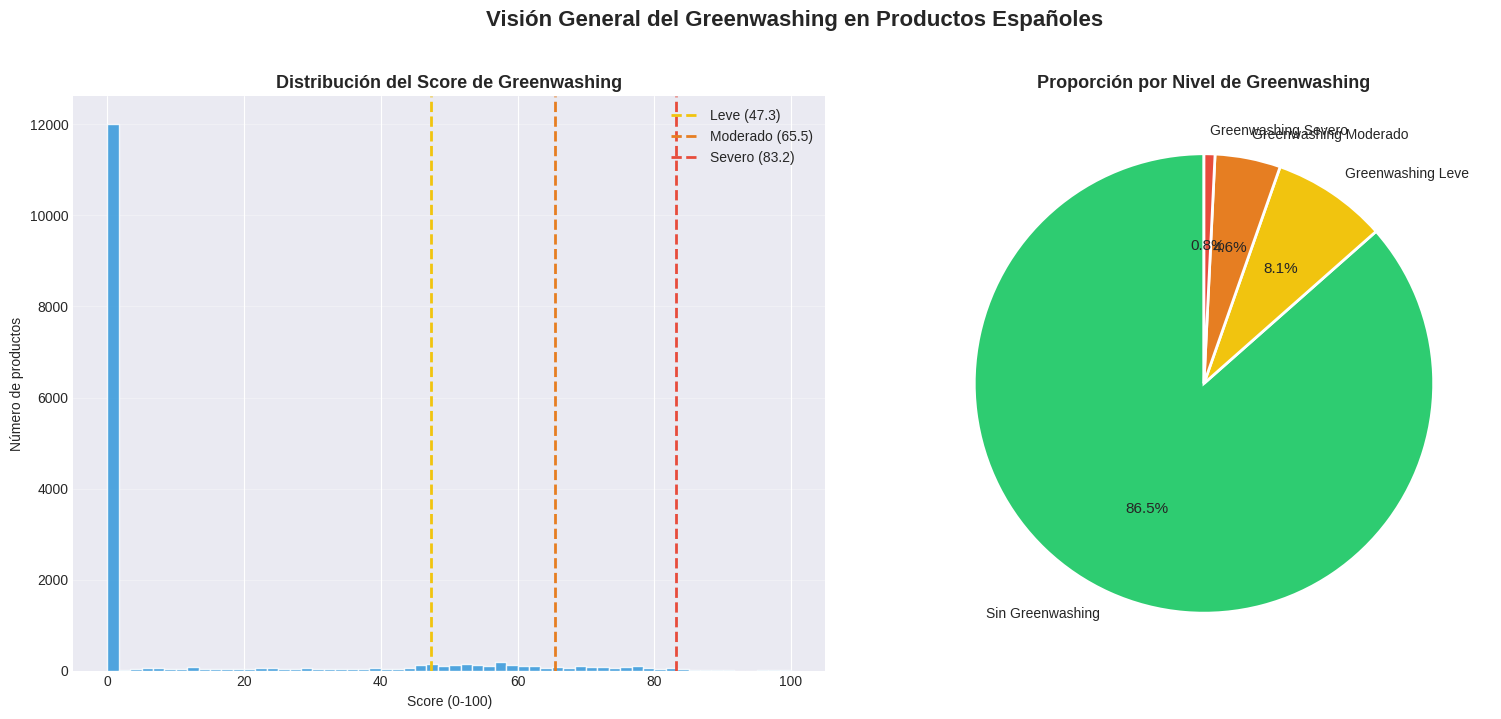

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Visión General del Greenwashing en Productos Españoles',
             fontsize=16, fontweight='bold', y=1.02)

axes[0].hist(df_products_analisis['greenwashing_score_100'],
             bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(p75, color='#f1c40f', linestyle='--', linewidth=2, label=f'Leve ({p75:.1f})')
axes[0].axvline(p90, color='#e67e22', linestyle='--', linewidth=2, label=f'Moderado ({p90:.1f})')
axes[0].axvline(p99, color='#e74c3c', linestyle='--', linewidth=2, label=f'Severo ({p99:.1f})')
axes[0].set_title('Distribución del Score de Greenwashing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score (0-100)')
axes[0].set_ylabel('Número de productos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

niveles = df_products_analisis['nivel_greenwashing'].value_counts().reindex(orden_niveles)
colores_pie = [colores_nivel[n] for n in orden_niveles]
wedges, texts, autotexts = axes[1].pie(
    niveles.values,
    labels=[n.split(' ', 1)[1] for n in orden_niveles],
    autopct='%1.1f%%',
    colors=colores_pie,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
axes[1].set_title('Proporción por Nivel de Greenwashing', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6845/372168361.py:47: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6845/372168361.py:47: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6845/372168361.py:47: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_6845/372168361.py:47: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

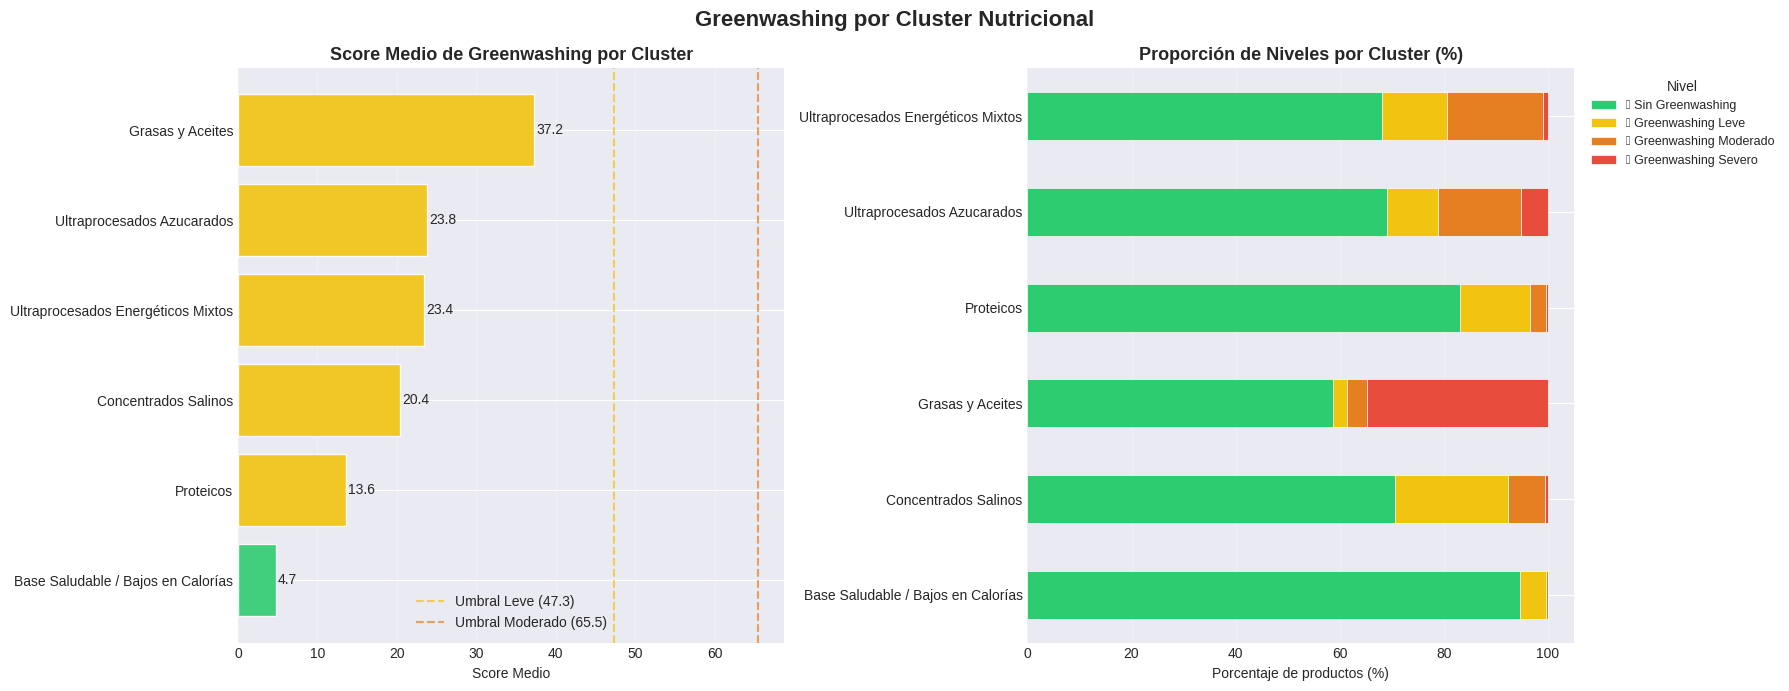

In [199]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Greenwashing por Cluster Nutricional',
             fontsize=16, fontweight='bold')


score_cluster = (df_products_analisis
                 .groupby('cluster_nombre')['greenwashing_score_100']
                 .mean()
                 .sort_values(ascending=True))

colores_barras = ['#e74c3c' if v > p90 else '#e67e22' if v > p75
                  else '#f1c40f' if v > 10 else '#2ecc71'
                  for v in score_cluster.values]

bars = axes[0].barh(score_cluster.index, score_cluster.values,
                    color=colores_barras, edgecolor='white', alpha=0.9)
axes[0].axvline(p75, color='#f1c40f', linestyle='--', alpha=0.7, label=f'Umbral Leve ({p75:.1f})')
axes[0].axvline(p90, color='#e67e22', linestyle='--', alpha=0.7, label=f'Umbral Moderado ({p90:.1f})')
for bar, val in zip(bars, score_cluster.values):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=10)
axes[0].set_title('Score Medio de Greenwashing por Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score Medio')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)


pivot = (df_products_analisis
         .groupby(['cluster_nombre', 'nivel_greenwashing'])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=orden_niveles, fill_value=0))

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(
    kind='barh', stacked=True, ax=axes[1],
    color=[colores_nivel[n] for n in orden_niveles],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Proporción de Niveles por Cluster (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Porcentaje de productos (%)')
axes[1].set_ylabel('')
axes[1].legend(title='Nivel', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

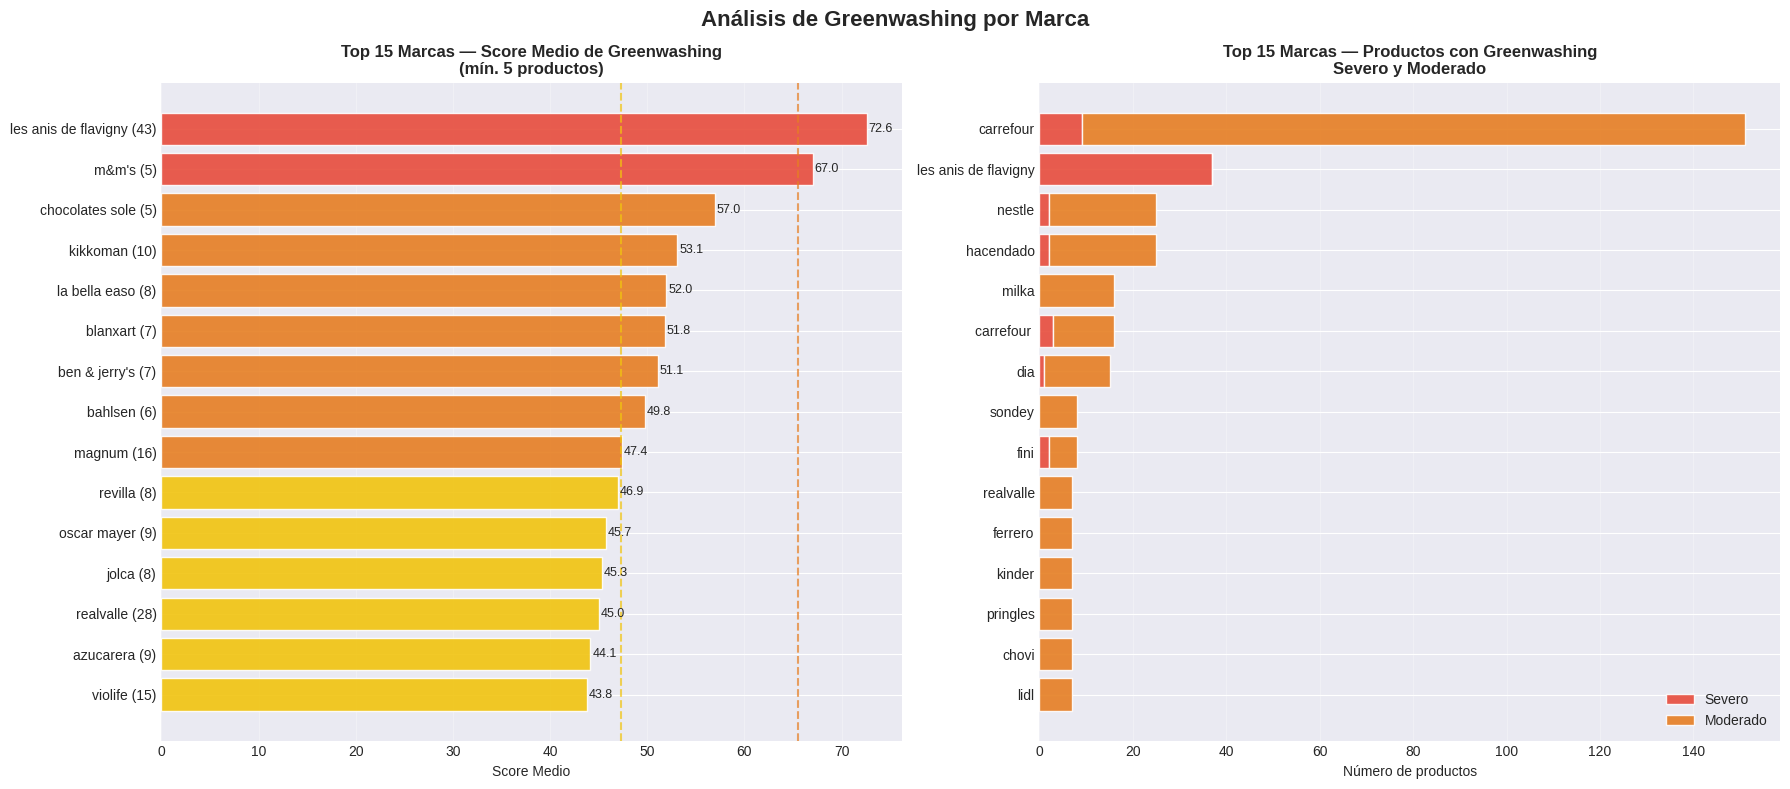

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Análisis de Greenwashing por Marca',
             fontsize=16, fontweight='bold')


marcas_stats = (df_products_analisis
                .groupby('brands')
                .agg(
                    score_medio=('greenwashing_score_100', 'mean'),
                    n_productos=('greenwashing_score_100', 'count'),
                    n_severo=('nivel_greenwashing',
                              lambda x: (x == '🔴 Greenwashing Severo').sum()),
                    n_moderado=('nivel_greenwashing',
                                lambda x: (x == '🟠 Greenwashing Moderado').sum())
                )
                .query('n_productos >= 5')
                .sort_values('score_medio', ascending=False))


top15 = marcas_stats.head(15)
colores_marcas = ['#e74c3c' if v > p90 else '#e67e22' if v > p75
                  else '#f1c40f' for v in top15['score_medio']]

bars = axes[0].barh(range(len(top15)), top15['score_medio'],
                    color=colores_marcas, edgecolor='white', alpha=0.9)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(
    [f"{m} ({n})" for m, n in zip(top15.index, top15['n_productos'])],
    fontsize=10
)
axes[0].invert_yaxis()
for bar, val in zip(bars, top15['score_medio']):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)
axes[0].axvline(p75, color='#f1c40f', linestyle='--', alpha=0.7)
axes[0].axvline(p90, color='#e67e22', linestyle='--', alpha=0.7)
axes[0].set_title('Top 15 Marcas — Score Medio de Greenwashing\n(mín. 5 productos)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score Medio')
axes[0].grid(axis='x', alpha=0.3)


marcas_stats['n_problematicos'] = marcas_stats['n_severo'] + marcas_stats['n_moderado']
top15_prob = marcas_stats.query('n_problematicos > 0').nlargest(15, 'n_problematicos')

axes[1].barh(range(len(top15_prob)), top15_prob['n_severo'],
             color='#e74c3c', alpha=0.9, label='Severo', edgecolor='white')
axes[1].barh(range(len(top15_prob)), top15_prob['n_moderado'],
             left=top15_prob['n_severo'],
             color='#e67e22', alpha=0.9, label='Moderado', edgecolor='white')
axes[1].set_yticks(range(len(top15_prob)))
axes[1].set_yticklabels(top15_prob.index, fontsize=10)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Marcas — Productos con Greenwashing\nSevero y Moderado',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de productos')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


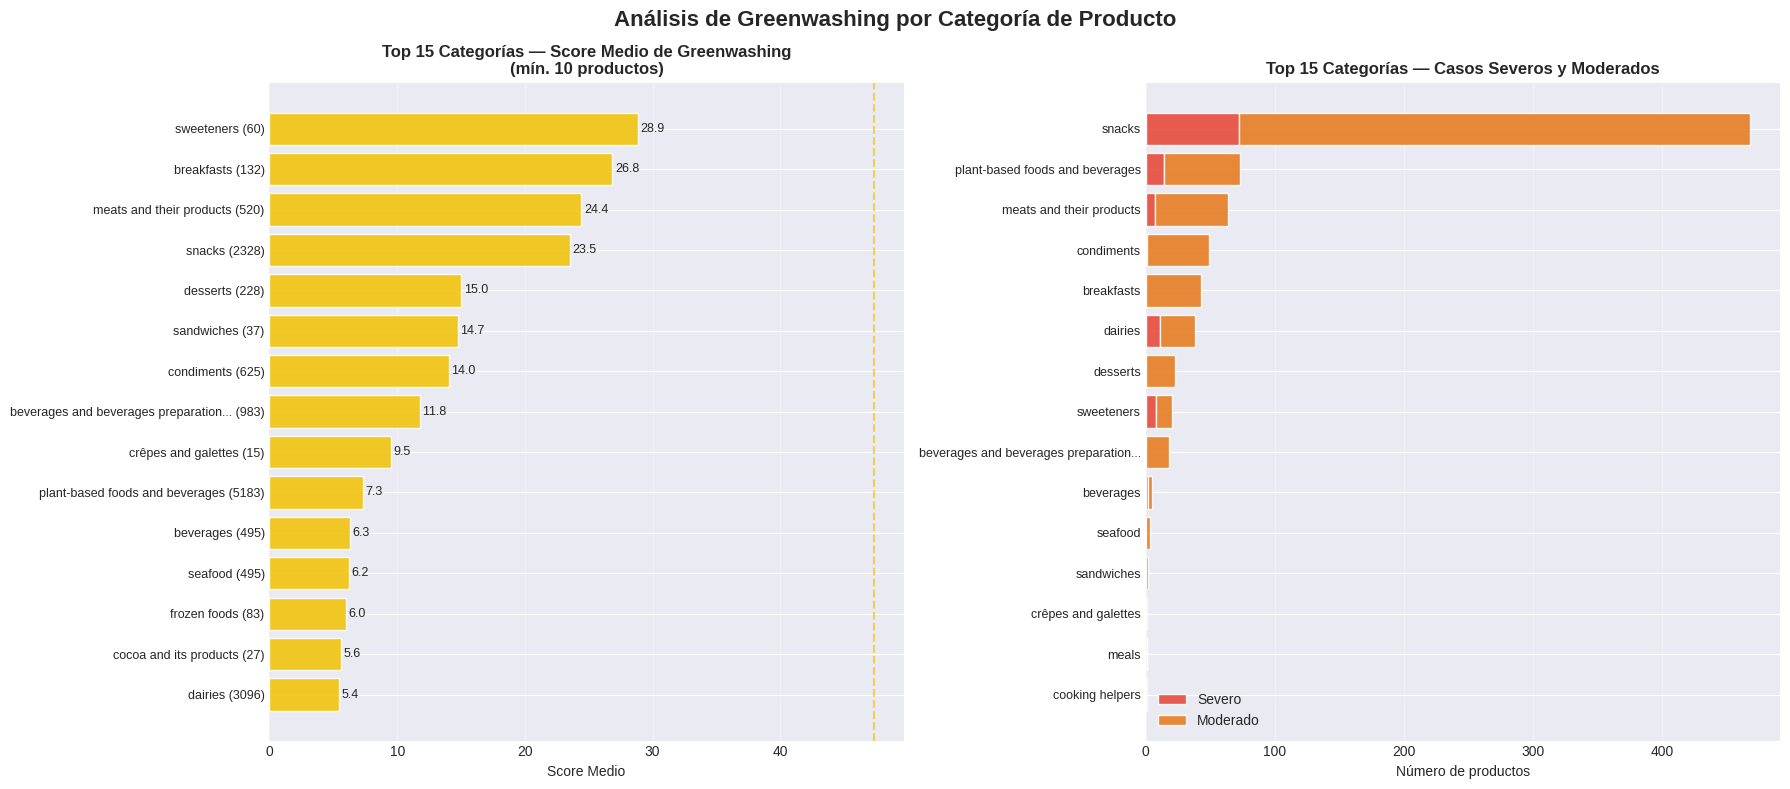

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Análisis de Greenwashing por Categoría de Producto',
             fontsize=16, fontweight='bold')


cats_stats = (df_products_analisis
              .groupby('categories_en')
              .agg(
                  score_medio=('greenwashing_score_100', 'mean'),
                  n_productos=('greenwashing_score_100', 'count'),
                  n_severo=('nivel_greenwashing',
                            lambda x: (x == '🔴 Greenwashing Severo').sum()),
                  n_moderado=('nivel_greenwashing',
                              lambda x: (x == '🟠 Greenwashing Moderado').sum())
              )
              .query('n_productos >= 10')
              .sort_values('score_medio', ascending=False))


top15_cat = cats_stats.head(15)
colores_cat = ['#e74c3c' if v > p90 else '#e67e22' if v > p75
               else '#f1c40f' for v in top15_cat['score_medio']]

bars = axes[0].barh(range(len(top15_cat)), top15_cat['score_medio'],
                    color=colores_cat, edgecolor='white', alpha=0.9)
axes[0].set_yticks(range(len(top15_cat)))
axes[0].set_yticklabels(
    [f"{c[:35]}... ({n})" if len(c) > 35 else f"{c} ({n})"
     for c, n in zip(top15_cat.index, top15_cat['n_productos'])],
    fontsize=9
)
axes[0].invert_yaxis()
for bar, val in zip(bars, top15_cat['score_medio']):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)
axes[0].axvline(p75, color='#f1c40f', linestyle='--', alpha=0.7)
axes[0].set_title('Top 15 Categorías — Score Medio de Greenwashing\n(mín. 10 productos)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score Medio')
axes[0].grid(axis='x', alpha=0.3)


cats_stats['n_problematicos'] = cats_stats['n_severo'] + cats_stats['n_moderado']
top15_cat_prob = cats_stats.query('n_problematicos > 0').nlargest(15, 'n_problematicos')

axes[1].barh(range(len(top15_cat_prob)), top15_cat_prob['n_severo'],
             color='#e74c3c', alpha=0.9, label='Severo', edgecolor='white')
axes[1].barh(range(len(top15_cat_prob)), top15_cat_prob['n_moderado'],
             left=top15_cat_prob['n_severo'],
             color='#e67e22', alpha=0.9, label='Moderado', edgecolor='white')
axes[1].set_yticks(range(len(top15_cat_prob)))
axes[1].set_yticklabels(
    [c[:35] + '...' if len(c) > 35 else c for c in top15_cat_prob.index],
    fontsize=9
)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Categorías — Casos Severos y Moderados',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de productos')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

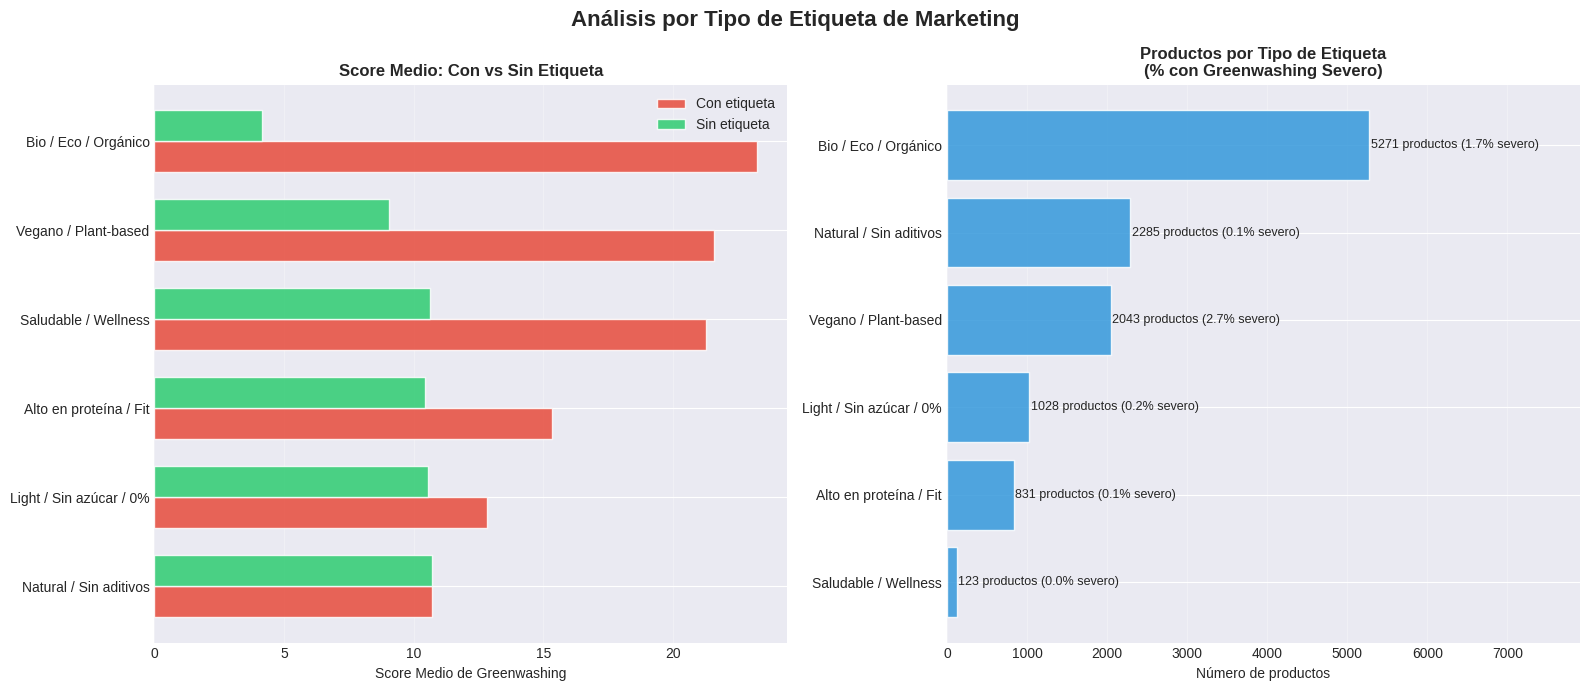

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Análisis por Tipo de Etiqueta de Marketing',
             fontsize=16, fontweight='bold')

etiquetas_labels = {
    'f_bio': 'Bio / Eco / Orgánico',
    'f_natural': 'Natural / Sin aditivos',
    'f_vegan': 'Vegano / Plant-based',
    'f_light': 'Light / Sin azúcar / 0%',
    'f_proteina': 'Alto en proteína / Fit',
    'f_salud': 'Saludable / Wellness'
}

resultados_etiquetas = []
for col, label in etiquetas_labels.items():
    con = df_products_analisis[df_products_analisis[col] == 1]
    sin = df_products_analisis[df_products_analisis[col] == 0]
    resultados_etiquetas.append({
        'etiqueta': label,
        'score_con': con['greenwashing_score_100'].mean(),
        'score_sin': sin['greenwashing_score_100'].mean(),
        'n_productos': len(con),
        'pct_severo': (con['nivel_greenwashing'] == '🔴 Greenwashing Severo').mean() * 100
    })

df_etiquetas = pd.DataFrame(resultados_etiquetas).sort_values('score_con', ascending=True)

x = np.arange(len(df_etiquetas))
width = 0.35
axes[0].barh(x - width/2, df_etiquetas['score_con'],
             width, label='Con etiqueta', color='#e74c3c', alpha=0.85, edgecolor='white')
axes[0].barh(x + width/2, df_etiquetas['score_sin'],
             width, label='Sin etiqueta', color='#2ecc71', alpha=0.85, edgecolor='white')
axes[0].set_yticks(x)
axes[0].set_yticklabels(df_etiquetas['etiqueta'], fontsize=10)
axes[0].set_title('Score Medio: Con vs Sin Etiqueta', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score Medio de Greenwashing')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)


df_etiquetas_sorted = df_etiquetas.sort_values('n_productos', ascending=True)
axes[1].barh(df_etiquetas_sorted['etiqueta'], df_etiquetas_sorted['n_productos'],
             color='#3498db', alpha=0.85, edgecolor='white')
for i, (val, pct) in enumerate(zip(df_etiquetas_sorted['n_productos'],
                                    df_etiquetas_sorted['pct_severo'])):
    axes[1].text(val + 20, i, f'{val} productos ({pct:.1f}% severo)',
                 va='center', fontsize=9)
axes[1].set_title('Productos por Tipo de Etiqueta\n(% con Greenwashing Severo)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de productos')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, df_etiquetas_sorted['n_productos'].max() * 1.5)

plt.tight_layout()
plt.show()

In [204]:
cols_mostrar = ['product_name', 'brands', 'categories_en',
                'greenwashing_score_100', 'nivel_greenwashing', 'cluster_nombre',
                'score_nutricional_norm', 'aditivos_norm', 'score_engano_etiquetas',
                'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'aditivos_score',
                'f_bio', 'f_natural', 'f_light', 'f_vegan', 'f_proteina', 'f_salud']

top20 = (df_products_analisis[cols_mostrar]
         .sort_values('greenwashing_score_100', ascending=False)
         .head(20))

print("\n" + "="*80)
print("🏆 TOP 20 PRODUCTOS CON MAYOR GREENWASHING")
print("="*80)
for i, (_, row) in enumerate(top20.iterrows(), 1):
    etiquetas_activas = [k.replace('f_', '') for k in
                         ['f_bio', 'f_natural', 'f_light', 'f_vegan', 'f_proteina', 'f_salud']
                         if row[k] == 1]
    print(f"\n{i:2}. {row['product_name'][:45]} | {row['brands']}")
    print(f"    Score: {row['greenwashing_score_100']:.1f}/100 | {row['nivel_greenwashing']}")
    print(f"    Cluster: {row['cluster_nombre']}")
    print(f"    Etiquetas que mienten: {row['score_engano_etiquetas']*100:.0f}%")
    print(f"    Etiquetas: {', '.join(etiquetas_activas) if etiquetas_activas else 'ninguna'}")
    print(f"    Nutrición: sat-fat={row['saturated-fat_100g']:.1f}g | "
          f"azúcar={row['sugars_100g']:.1f}g | sal={row['salt_100g']:.1f}g | "
          f"aditivos_score={row['aditivos_score']:.0f}")


🏆 TOP 20 PRODUCTOS CON MAYOR GREENWASHING

 1. aceite de coco virgen extra | la masia
    Score: 100.0/100 | 🔴 Greenwashing Severo
    Cluster: Grasas y Aceites
    Etiquetas que mienten: 100%
    Etiquetas: bio
    Nutrición: sat-fat=95.0g | azúcar=0.0g | sal=0.0g | aditivos_score=0

 2. bio kokosöl | meracus
    Score: 99.7/100 | 🔴 Greenwashing Severo
    Cluster: Grasas y Aceites
    Etiquetas que mienten: 100%
    Etiquetas: bio
    Nutrición: sat-fat=94.2g | azúcar=0.0g | sal=0.0g | aditivos_score=0

 3. aceite de coco virgen extra | veritas
    Score: 99.6/100 | 🔴 Greenwashing Severo
    Cluster: Grasas y Aceites
    Etiquetas que mienten: 100%
    Etiquetas: bio
    Nutrición: sat-fat=93.9g | azúcar=0.0g | sal=0.0g | aditivos_score=0

 4. 100% organic coconut oil | prozis
    Score: 99.6/100 | 🔴 Greenwashing Severo
    Cluster: Grasas y Aceites
    Etiquetas que mienten: 100%
    Etiquetas: bio, light, vegan
    Nutrición: sat-fat=94.0g | azúcar=0.0g | sal=0.0g | aditivos_score